# **Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyarrow
import warnings
warnings.filterwarnings('ignore')


# Rojo  → Charged Off (default=1)  |  Azul → Fully Paid (default=0)
CMAP        = 'RdYlBu'               # colormap continuo
C_PAID      = '#4393C3'              # azul  – Fully Paid
C_DEFAULT   = '#D6604D'              # rojo  – Charged Off
PALETTE_2   = [C_PAID, C_DEFAULT]    # [0, 1]
PALETTE_DIV = sns.color_palette(CMAP, n_colors=10)  # para categóricas

# Estilo global
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 12,
})

## **Carga y Preparacion de Datos**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df_acc = pd.read_csv(
    '/content/drive/MyDrive/Datasets/Miniproyecto 1/accepted_2007_to_2018Q4.csv',
    low_memory=False
)
print(f'Dataset cargado: {df_acc.shape[0]:,} filas × {df_acc.shape[1]} columnas')

Mounted at /content/drive
Dataset cargado: 2,260,701 filas × 151 columnas


In [3]:
df_acc.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Filtrado a estados finales y creación del target
df = df_acc[df_acc['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

print(f'\nRegistros tras filtrado: {df.shape[0]:,}')


Registros tras filtrado: 1,345,310


In [5]:
# Selección de features
selected_features = [
    'loan_amnt',        # Monto del préstamo
    'int_rate',         # Tasa de interés
    'fico_range_high',  # Puntuación FICO (límite superior)
    'emp_length',       # Antigüedad laboral
    'annual_inc',       # Ingreso anual
    'purpose',          # Propósito del préstamo
    'home_ownership',   # Situación de la vivienda
    'dti',              # Ratio deuda-ingreso
    'addr_state',       # Estado de residencia
    'default'           # Variable objetivo
]

df_subset = df[selected_features].copy()

print('── Información general ──')
df_subset.info()

print('\n── Valores faltantes (%) ──')
miss = (df_subset.isnull().sum() / len(df_subset) * 100).sort_values(ascending=False)
print(miss[miss > 0].round(2).to_string())

── Información general ──
<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   loan_amnt        1345310 non-null  float64
 1   int_rate         1345310 non-null  float64
 2   fico_range_high  1345310 non-null  float64
 3   emp_length       1266799 non-null  object 
 4   annual_inc       1345310 non-null  float64
 5   purpose          1345310 non-null  object 
 6   home_ownership   1345310 non-null  object 
 7   dti              1344936 non-null  float64
 8   addr_state       1345310 non-null  object 
 9   default          1345310 non-null  int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 112.9+ MB

── Valores faltantes (%) ──
emp_length    5.84
dti           0.03


## **Analisis Exploratorio de Datos**

## **Distribucion de la Variable Target**

          Clase  Conteo  Porcentaje
 Fully Paid (0) 1076751       80.04
Charged Off (1)  268559       19.96


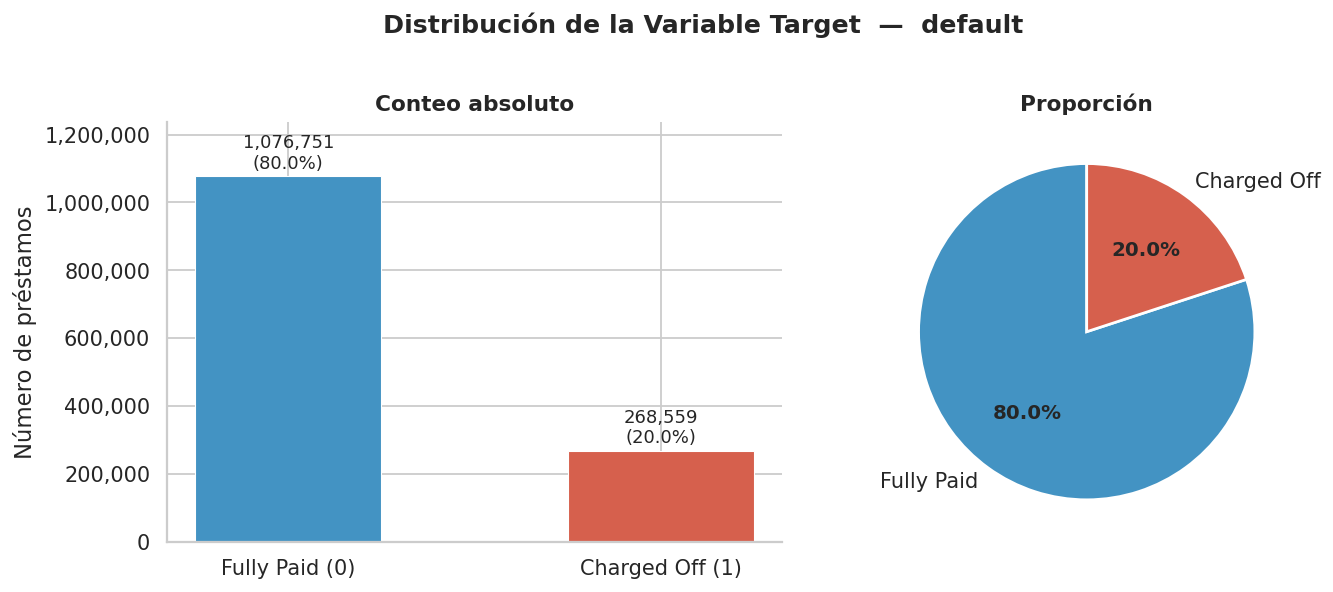

In [6]:
counts = df_subset['default'].value_counts().sort_index()
props  = counts / counts.sum() * 100

summary = pd.DataFrame({
    'Clase'     : ['Fully Paid (0)', 'Charged Off (1)'],
    'Conteo'    : counts.values,
    'Porcentaje': props.round(2).values
})
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Distribución de la Variable Target  —  default', fontsize=14, fontweight='bold', y=1.01)

# Barras
bars = axes[0].bar(['Fully Paid (0)', 'Charged Off (1)'], counts.values,
                   color=PALETTE_2, edgecolor='white', linewidth=0.6, width=0.5)
for bar, cnt, pct in zip(bars, counts.values, props.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Conteo absoluto')
axes[0].set_ylabel('Número de préstamos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=['Fully Paid', 'Charged Off'],
    colors=PALETTE_2,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

Podemos apreciar un claro desbalanceo de clases. Esto supondra un problema para el modelo a la hora de predecir, y sera comun ver un grtan volumen de Falsos Negativos.

## **Estadisticas Descriptivas**

In [7]:
num_cols = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti']

desc = df_subset.groupby('default')[num_cols].describe().T
desc.columns = ['Fully Paid (0)', 'Charged Off (1)']

# Mostrar solo las estadísticas más relevantes
stats_to_show = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
print('── Estadísticas descriptivas por clase ──\n')
print(desc.loc[(slice(None), stats_to_show), :].round(2).to_string())

── Estadísticas descriptivas por clase ──

                      Fully Paid (0)  Charged Off (1)
loan_amnt       mean        14134.37         15565.06
                std          8669.03          8814.56
                min           500.00           900.00
                25%          7500.00          9000.00
                50%         12000.00         14350.00
                75%         20000.00         20400.00
                max         40000.00         40000.00
int_rate        mean           12.62            15.71
                std             4.53             4.91
                min             5.31             5.31
                25%             9.17            12.29
                50%            12.23            15.05
                75%            15.31            18.55
                max            30.99            30.99
fico_range_high mean          702.26           691.85
                std            32.83            25.95
                min           629.00   

## **Distribucion de Variables Numericas**

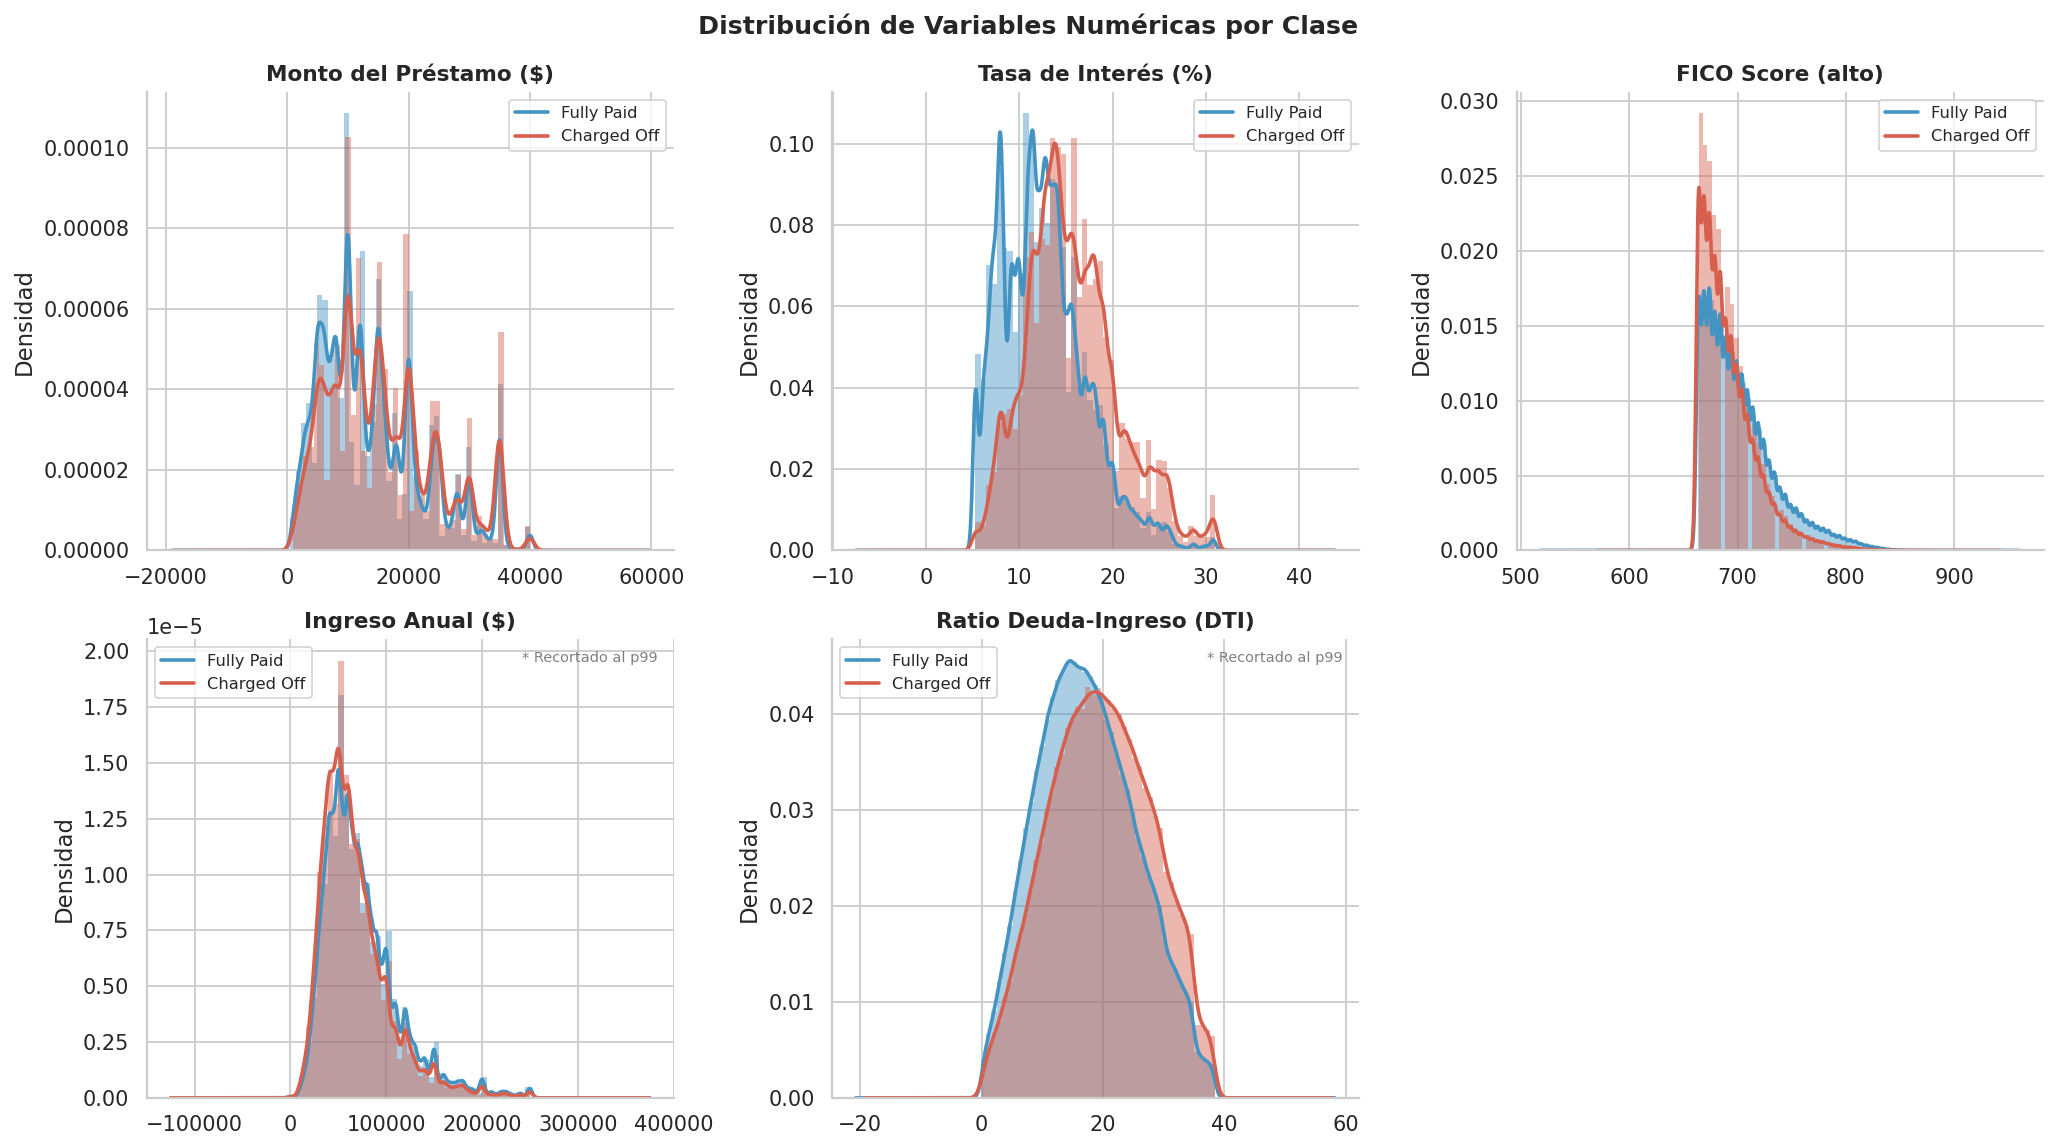

In [8]:
num_cols  = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti']
col_names = {
    'loan_amnt'       : 'Monto del Préstamo ($)',
    'int_rate'        : 'Tasa de Interés (%)',
    'fico_range_high' : 'FICO Score (alto)',
    'annual_inc'      : 'Ingreso Anual ($)',
    'dti'             : 'Ratio Deuda-Ingreso (DTI)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de Variables Numéricas por Clase', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

# Límites de percentil para recortar outliers extremos en la visualización
clip_p = {'annual_inc': 99, 'loan_amnt': 100, 'int_rate': 100,
          'fico_range_high': 100, 'dti': 99}

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    pct = clip_p.get(col, 100)
    clip_val = df_subset[col].quantile(pct / 100)
    data_clipped = df_subset[df_subset[col] <= clip_val]

    for val, label, color in zip([0, 1], ['Fully Paid', 'Charged Off'], PALETTE_2):
        subset = data_clipped[data_clipped['default'] == val][col].dropna()
        ax.hist(subset, bins=45, alpha=0.45, color=color, density=True, edgecolor='none')
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=label)

    ax.set_title(col_names[col])
    ax.set_xlabel('')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    if pct < 100:
        ax.annotate(f'* Recortado al p{pct}', xy=(0.97, 0.95), xycoords='axes fraction',
                    ha='right', fontsize=8, color='gray')

# Apagar el subplot sobrante
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

## **Boxplots por Clase**

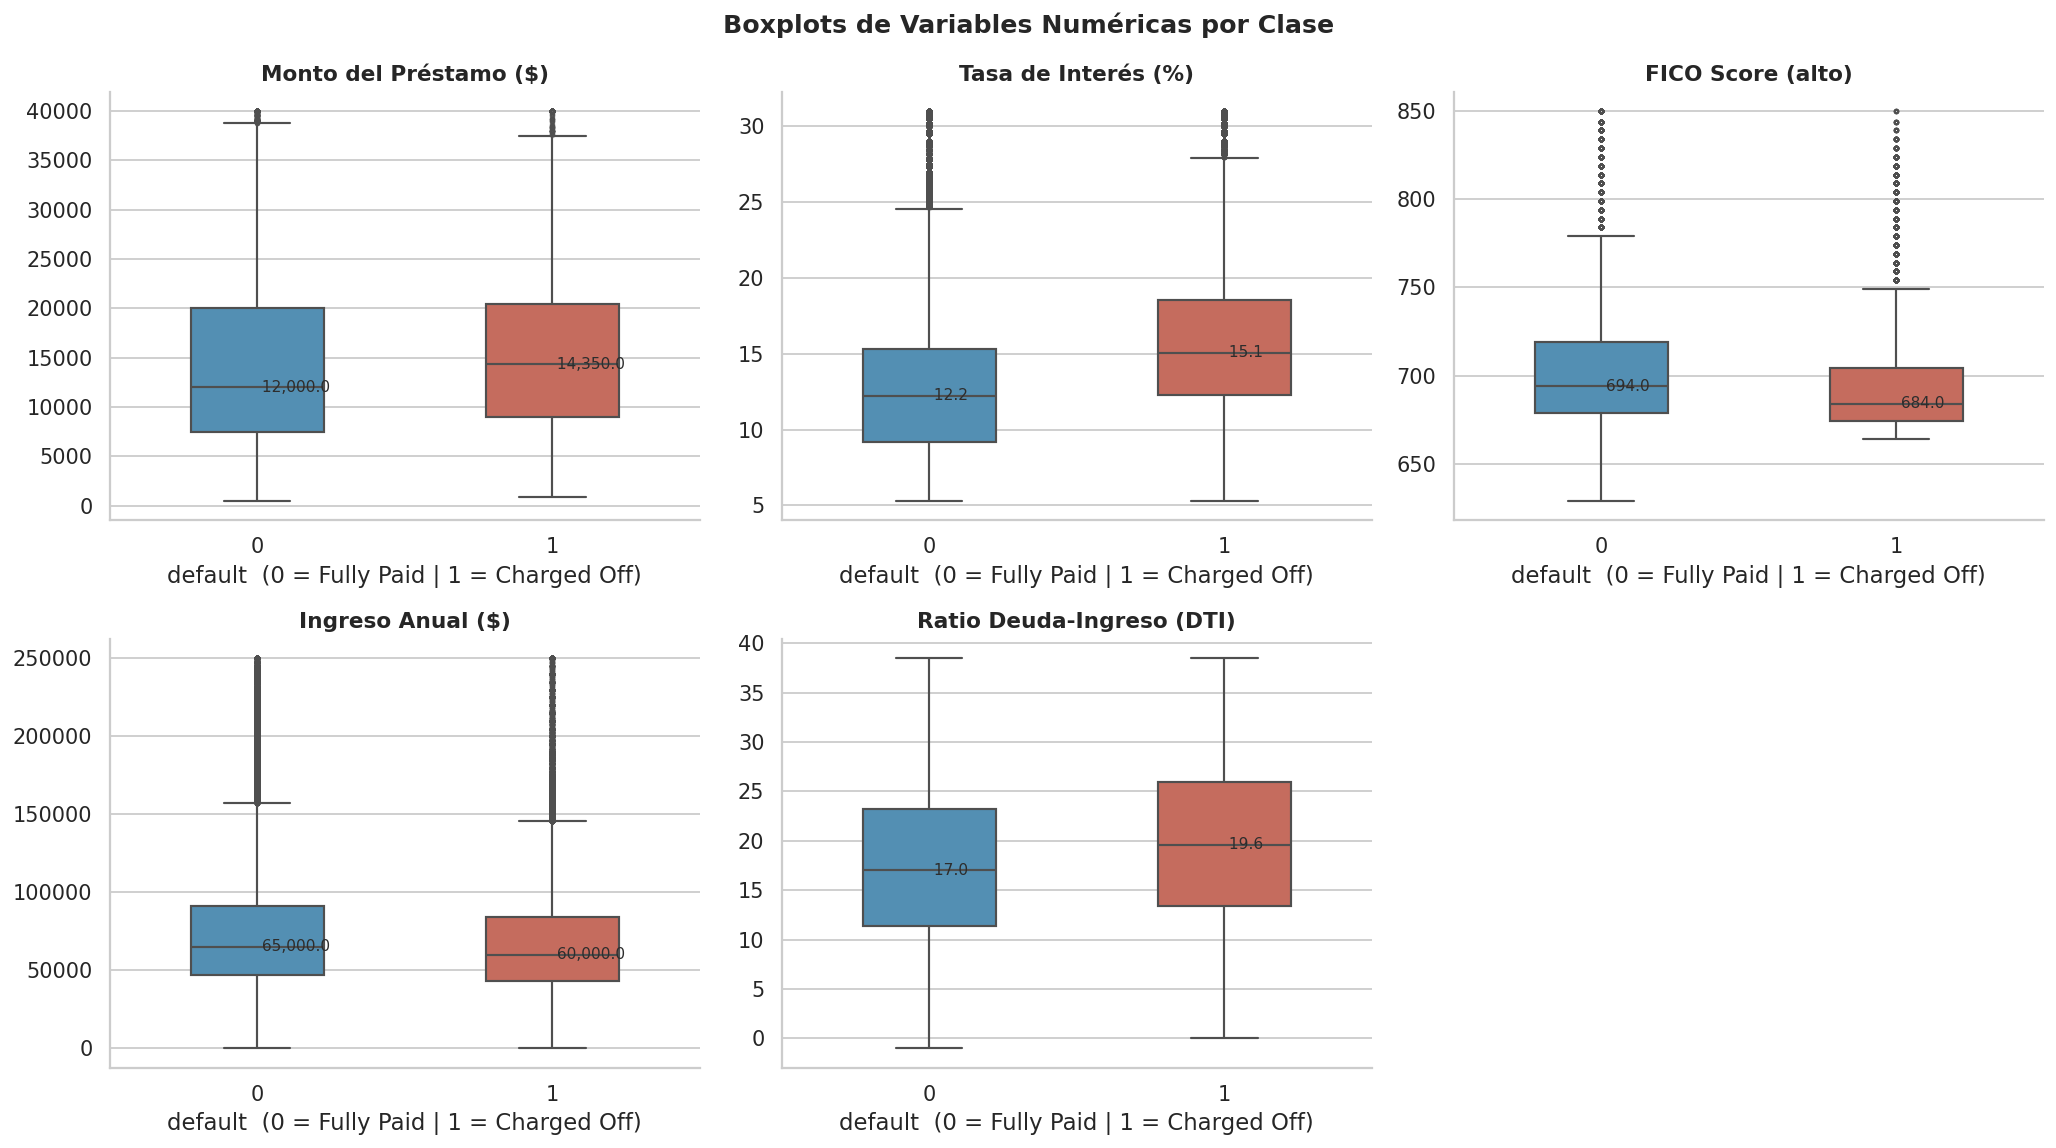

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Boxplots de Variables Numéricas por Clase', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    pct = clip_p.get(col, 100)
    clip_val = df_subset[col].quantile(pct / 100)
    data_clipped = df_subset[df_subset[col] <= clip_val][['default', col]].dropna()

    sns.boxplot(
        data=data_clipped, x='default', y=col,
        palette={'0': C_PAID, '1': C_DEFAULT},
        width=0.45, linewidth=1.2,
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        ax=ax
    )
    ax.set_title(col_names[col])
    ax.set_xlabel('default  (0 = Fully Paid | 1 = Charged Off)')
    ax.set_ylabel('')

    # Mediana anotada
    for cls in [0, 1]:
        med = data_clipped[data_clipped['default'] == cls][col].median()
        ax.text(cls, med, f' {med:,.1f}', va='center', fontsize=8.5, color='#2d2d2d')

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
num_cols = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti'] # Removed 'emp_length'

rows = []
for col in num_cols:
    Q1  = df_subset[col].quantile(0.25)
    Q3  = df_subset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_subset[col] < lower) | (df_subset[col] > upper)).sum()
    pct        = n_outliers / df_subset[col].notna().sum() * 100
    p99        = df_subset[col].quantile(0.99)
    max_val    = df_subset[col].max()

    rows.append({
        'feature'    : col,
        'Q1'         : Q1,
        'Q3'         : Q3,
        'IQR'        : IQR,
        'lower_fence': lower,
        'upper_fence': upper,
        'max'        : max_val,
        'p99'        : p99,
        'n_outliers' : n_outliers,
        'pct_outliers': round(pct, 2)
    })

outlier_df = pd.DataFrame(rows).set_index('feature')
print('── Análisis de Outliers (criterio IQR) ──\n')
print(outlier_df.round(2).to_string())

── Análisis de Outliers (criterio IQR) ──

                       Q1        Q3       IQR  lower_fence  upper_fence          max        p99  n_outliers  pct_outliers
feature                                                                                                                  
loan_amnt         8000.00  20000.00  12000.00    -10000.00     38000.00     40000.00   35000.00        7157          0.53
int_rate             9.75     15.99      6.24         0.39        25.35        30.99      26.30       24977          1.86
fico_range_high    674.00    714.00     40.00       614.00       774.00       850.00     804.00       46497          3.46
annual_inc       45780.00  90000.00  44220.00    -20550.00    156330.00  10999200.00  250000.00       65870          4.90
dti                 11.79     24.06     12.27        -6.62        42.46       999.00      38.47        5473          0.41


Haciendo un anailisis de las distribuciones de las variables numericas, las mas problematicas son **Ingreso Anual** y **DTI**, por tal motivo se realizara una transformacion logaritmica de estas variables antes del modelamiento.

| Variable         | Decisión         | Justificación                                      |
|------------------|------------------|----------------------------------------------------|
| loan_amnt        | Sin tratamiento  | Variable Acotada               |
| int_rate         | Sin tratamiento  | Variable Acotada               |
| fico_range_high  | Sin tratamiento  | 850 es el máximo teórico posible                   |
| annual_inc       | log1p            | Valores extremos reales pero muy sesgados          |
| dti              | log1p            | Valor máximo de 999        |
| emp_length       | Sin tratamiento  | Variable discreta 0–10, sin outliers               |

# **Tasa de Defaul por Categoria**

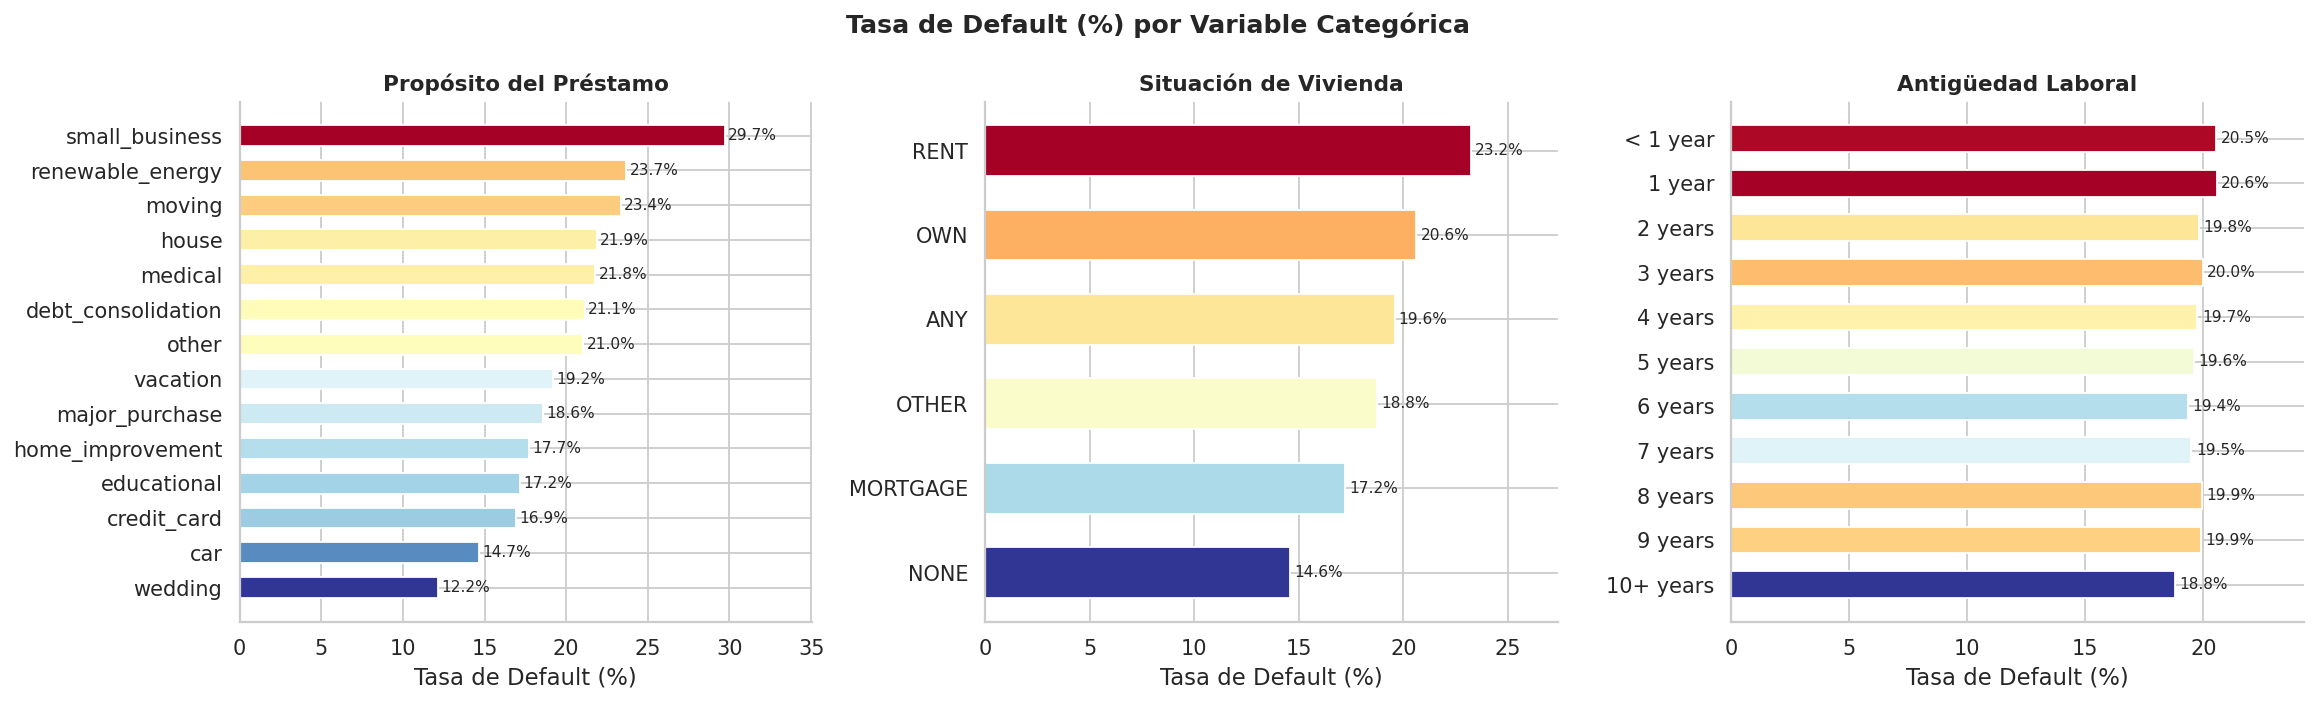

In [10]:
cat_cols = {
    'purpose'       : 'Propósito del Préstamo',
    'home_ownership': 'Situación de Vivienda',
    'emp_length'    : 'Antigüedad Laboral'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Tasa de Default (%) por Variable Categórica', fontsize=14, fontweight='bold')

# Orden de emp_length lógico
emp_order = ['< 1 year','1 year','2 years','3 years','4 years',
             '5 years','6 years','7 years','8 years','9 years','10+ years']

for ax, (col, title) in zip(axes, cat_cols.items()):
    rate = (
        df_subset.groupby(col)['default']
        .mean()
        .mul(100)
        .round(2)
        .reset_index()
        .rename(columns={'default': 'default_rate'})
    )

    if col == 'emp_length':
        rate['sort_key'] = rate[col].map({v: i for i, v in enumerate(emp_order)})
        rate = rate.dropna(subset=['sort_key']).sort_values('sort_key')
    else:
        rate = rate.sort_values('default_rate', ascending=False)

    # Colorear barras por tasa (mapa RdYlBu invertido: rojo=alto default)
    norm_vals = (rate['default_rate'] - rate['default_rate'].min()) / \
                (rate['default_rate'].max() - rate['default_rate'].min() + 1e-9)
    colors = plt.cm.RdYlBu_r(norm_vals)

    bars = ax.barh(rate[col], rate['default_rate'], color=colors, edgecolor='white', height=0.6)

    for bar, val in zip(bars, rate['default_rate']):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8.5)

    ax.set_title(title)
    ax.set_xlabel('Tasa de Default (%)')
    ax.set_xlim(0, rate['default_rate'].max() * 1.18)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

*   **Propósito**: small_business con 29.7% destaca claramente del resto. Los préstamos de negocio tienen un perfil de riesgo fundamentalmente diferente, flujo de caja incierto, dependencia de factores externos. wedding con 12.2% es el más seguro, lo cual también tiene lógica — es un gasto puntual con motivación fuerte para cumplir.
*   **Situación de vivienda**: la diferencia entre RENT (23.2%) y MORTGAGE (17.2%) es significativa y contraintuitiva a primera vista. Uno podría pensar que quien tiene hipoteca tiene más compromisos y mayor riesgo, pero tener hipoteca aprobada podria ser una señal de solvencia crediticia previa. NONE con 14.6% es interesante, probablemente personas que viven con familiares sin gastos de vivienda fija.
* **Antigüedad laboral**: aquí la gráfica es casi plana. Esto sugiere que emp_length probablemente tiene poco poder predictivo individual.


## **Tasa de Default por Estado**

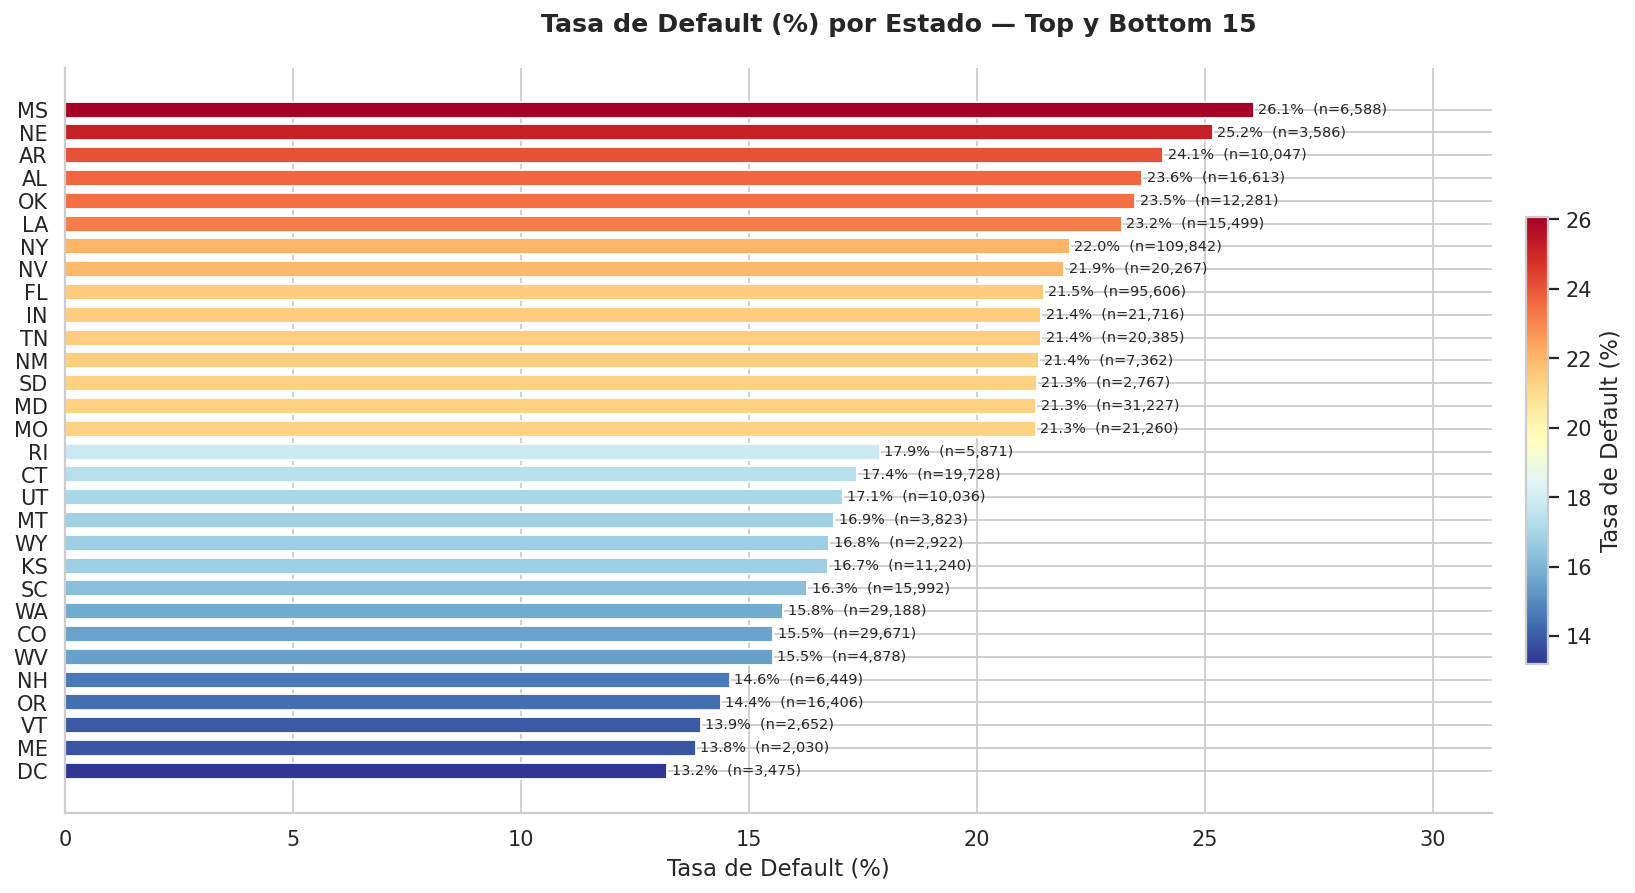

In [11]:
state_rate = (
    df_subset.groupby('addr_state')['default']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n_loans'})
    .reset_index()
)
state_rate['default_rate'] = (state_rate['default_rate'] * 100).round(2)

# Filtrar estados con al menos 500 préstamos para evitar ruido
state_rate = state_rate[state_rate['n_loans'] >= 500].sort_values('default_rate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Tasa de Default (%) por Estado — Top y Bottom 15', fontsize=14, fontweight='bold')

top15    = state_rate.head(15)
bottom15 = state_rate.tail(15)
combined = pd.concat([top15, bottom15]).drop_duplicates()

norm_vals = (combined['default_rate'] - combined['default_rate'].min()) / \
            (combined['default_rate'].max() - combined['default_rate'].min() + 1e-9)
colors = plt.cm.RdYlBu_r(norm_vals)

bars = ax.barh(combined['addr_state'], combined['default_rate'],
               color=colors, edgecolor='white', height=0.7)

for bar, row in zip(bars, combined.itertuples()):
    ax.text(row.default_rate + 0.1, bar.get_y() + bar.get_height()/2,
            f'{row.default_rate:.1f}%  (n={row.n_loans:,})',
            va='center', fontsize=8)

ax.set_xlabel('Tasa de Default (%)')
ax.set_xlim(0, combined['default_rate'].max() * 1.2)
ax.invert_yaxis()

# Colorbar de referencia
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r',
                            norm=plt.Normalize(combined['default_rate'].min(),
                                               combined['default_rate'].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Tasa de Default (%)', shrink=0.6, pad=0.02)

plt.tight_layout()
plt.show()

Parece ser que addr_state aporta señal real y que podra ser una feature de gran importancia para el modelo.

## **Matriz de Correlacion**

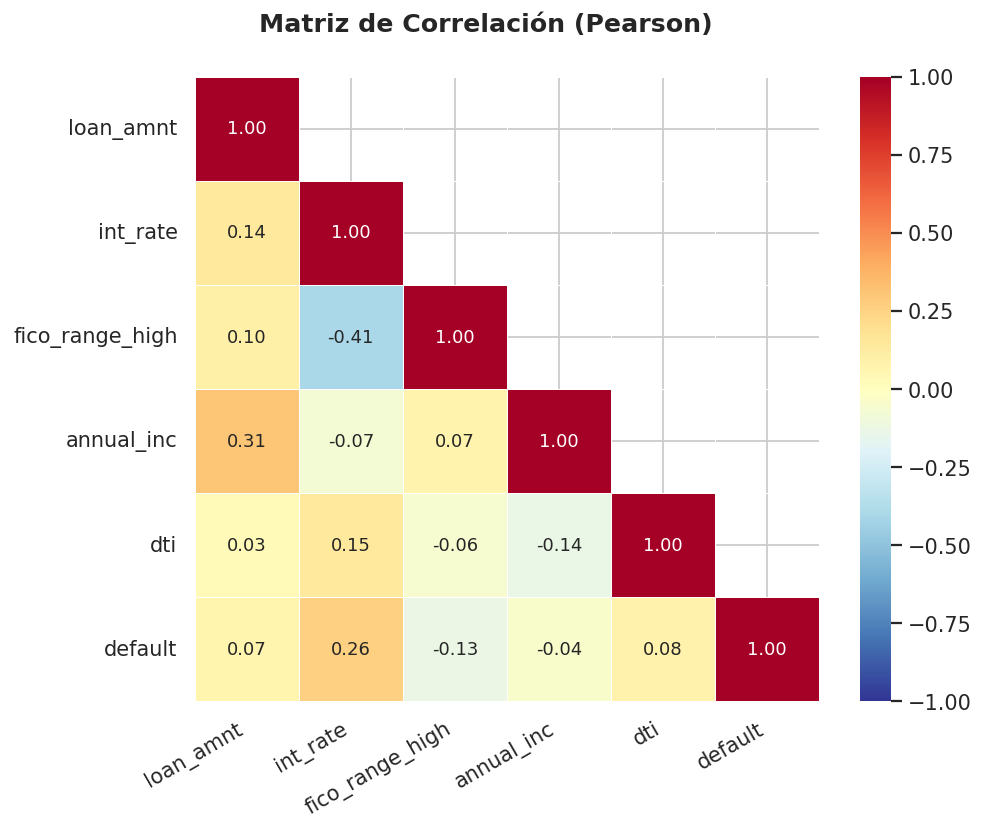


── Correlación con la variable target (default) ──
int_rate           0.2588
fico_range_high   -0.1307
dti                0.0845
loan_amnt          0.0656
annual_inc        -0.0418


In [12]:
# Solo variables numéricas + target
corr_cols = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'default']
corr_df   = df_subset[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
fig.suptitle('Matriz de Correlación (Pearson)', fontsize=14, fontweight='bold')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # triángulo superior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    annot_kws={'size': 10},
    ax=ax
)

# Resaltar columna/fila de 'default'
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print('\n── Correlación con la variable target (default) ──')
print(corr_matrix['default'].drop('default').sort_values(key=abs, ascending=False).round(4).to_string())

Tres cosas llaman la atención:
*   int_rate con 0.26 de correlación con default es la variable numérica más predictiva, lo cual es intuitivo — tasas altas reflejan que Lending Club ya percibía mayor riesgo en ese préstamo al momento de emitirlo.
*   fico_range_high con -0.41 con int_rate es la correlación más fuerte del dataset. No es sorprendente — a mejor score crediticio, menor tasa asignada. Pero esto sugiere multicolinealidad moderada entre dos de nuestras features.
* Lo preocupante: annual_inc y dti tienen correlaciones casi nulas con default (−0.04 y 0.08). Eso no significa que no sean útiles — Random Forest captura interacciones no lineales.

## **Analisis de Datos Faltantes**

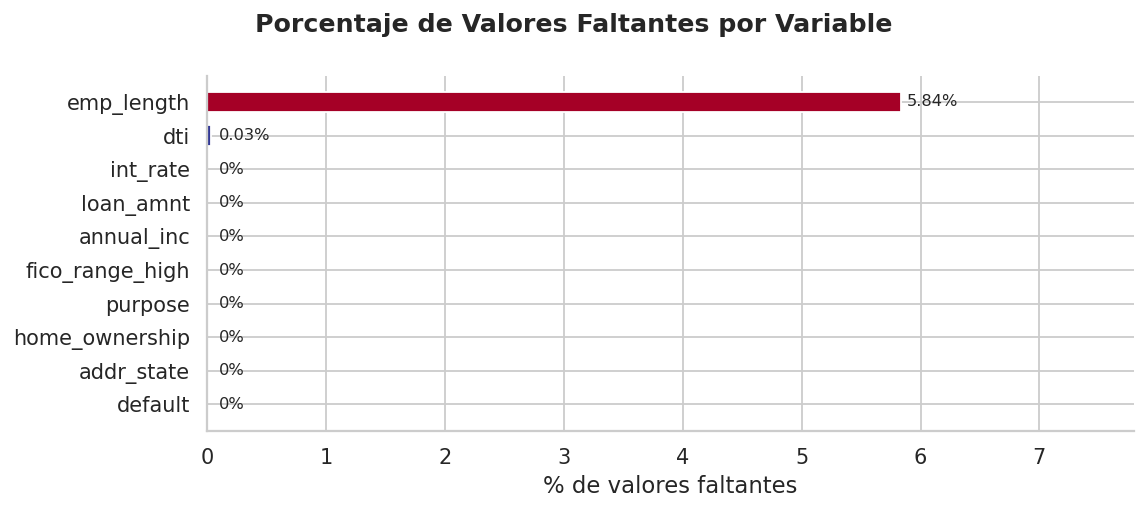


Resumen:
        feature  missing_pct
     emp_length     5.835904
            dti     0.027800
       int_rate     0.000000
      loan_amnt     0.000000
     annual_inc     0.000000
fico_range_high     0.000000
        purpose     0.000000
 home_ownership     0.000000
     addr_state     0.000000
        default     0.000000


In [13]:
miss_pct = (df_subset.isnull().sum() / len(df_subset) * 100).sort_values(ascending=False)
miss_df   = miss_pct.reset_index()
miss_df.columns = ['feature', 'missing_pct']

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')

norm_miss = miss_df['missing_pct'] / (miss_df['missing_pct'].max() + 1e-9)
colors    = plt.cm.RdYlBu_r(norm_miss)

bars = ax.barh(miss_df['feature'], miss_df['missing_pct'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, miss_df['missing_pct']):
    label = f'{val:.2f}%' if val > 0 else '0%'
    ax.text(max(val + 0.05, 0.1), bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

ax.set_xlabel('% de valores faltantes')
ax.set_xlim(0, miss_df['missing_pct'].max() * 1.25 + 0.5)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print('\nResumen:')
print(miss_df.to_string(index=False))

Solo dos features presentan valores faltantes y se decidio hacer imputacion mediante la mediana.

# **Preprocesamiento**

## **Limpieza**

La variable `emp_length` viene como string (`"10+ years"`, `"< 1 year"`, etc.).
Se extrae el valor numérico y se imputan los NaN con la **mediana**.

In [14]:
import re

def parse_emp_length(val):
    """Convierte emp_length string a entero.
    '< 1 year' -> 0  |  '10+ years' -> 10  |  '5 years' -> 5
    """
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith('<'):
        return 0
    match = re.search(r'(\d+)', val)
    return int(match.group(1)) if match else np.nan

df_parsed = df_subset.copy()
df_parsed['emp_length'] = df_parsed['emp_length'].apply(parse_emp_length)

# **Dataset to .parquet**
Con el objetivo de obtener un mejor rendimiento a la hora de hacer el modelado y optimizar los escazoz recursos con los que se cuenta se ha decidido convertir el set de datos de .csv a .parquet

In [ ]:
PATH = '/content/drive/MyDrive/Datasets/Miniproyecto 1/df_parsed.parquet'

df_parsed.to_parquet(PATH, index=False)

In [ ]:
PATH = '/kaggle/input/datasets/luiscabarcas/loan-accepted'
df_parsed = pd.read_parquet(PATH)

### **Split — Train / Test (80/20)**

In [ ]:
from sklearn.model_selection import train_test_split

NUM_FEATURES = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'emp_length']
CAT_FEATURES = ['purpose', 'home_ownership', 'addr_state']
TARGET       = 'default'

X = df_parsed[NUM_FEATURES + CAT_FEATURES]
y = df_parsed[TARGET]

# Split estratificado 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

total = X.shape[0]
print(f'Total  : {total:>10,}  (100.0%)')
print(f'Train  : {X_train_raw.shape[0]:>10,}  ({X_train_raw.shape[0]/total*100:.1f}%)')
print(f'Test   : {X_test_raw.shape[0]:>10,}  ({X_test_raw.shape[0]/total*100:.1f}%)')
print(f'\nProporción default - Train: {y_train.mean()*100:.2f}%  Test: {y_test.mean()*100:.2f}%')

Total  :  1,345,310  (100.0%)
Train  :  1,076,248  (80.0%)
Test   :    269,062  (20.0%)

Proporción default - Train: 19.96%  Test: 19.96%


In [ ]:
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

# Transformación log1p sobre annual_inc y dti
# — fit implícito en train, misma transformación aplicada a test
log_cols = ['annual_inc', 'dti']

for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

# Reemplazar -inf/inf que pueda generar log1p sobre valores <= 0
for df_set in [X_train, X_test]:
    df_set['dti'] = df_set['dti'].replace([-np.inf, np.inf], np.nan)

# Imputación con medianas calculadas exclusivamente en train
emp_median_train = X_train['emp_length'].median()
dti_median_train = X_train['dti'].median()

X_train['emp_length'] = X_train['emp_length'].fillna(emp_median_train)
X_test['emp_length']  = X_test['emp_length'].fillna(emp_median_train)

X_train['dti'] = X_train['dti'].fillna(dti_median_train)
X_test['dti']  = X_test['dti'].fillna(dti_median_train)

## **Preprocesamiento — scikit-learn**

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose        import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),
                              NUM_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                              CAT_FEATURES)
    ],
    remainder='passthrough'
)

# fit SOLO sobre train — transform sobre train y test
X_train_sk = preprocessor.fit_transform(X_train)
X_test_sk  = preprocessor.transform(X_test)

# Nombres de features resultantes
ohe_feature_names = preprocessor.named_transformers_['cat'] \
                    .get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = NUM_FEATURES + ohe_feature_names

print(f'Dimensiones X_train_sk : {X_train_sk.shape}')
print(f'Dimensiones X_test_sk  : {X_test_sk.shape}')
print(f'Total features         : {len(all_feature_names)}')
print(f'  Numéricas            : {len(NUM_FEATURES)}')
print(f'  One-Hot              : {len(ohe_feature_names)}')

Dimensiones X_train_sk : (1076248, 77)
Dimensiones X_test_sk  : (269062, 77)
Total features         : 77
  Numéricas            : 6
  One-Hot              : 71


---
# **Modelado — scikit-learn**

Se entrena un `RandomForestClassifier` con búsqueda de hiperparámetros via `GridSearchCV`.

> **¿Por qué ROC AUC como scoring?** Con un dataset desbalanceado 80/20, ROC AUC evalúa
> la capacidad del modelo para **separar las dos clases a lo largo de todos los umbrales**,
> sin asumir un punto de corte fijo. Esto lo hace consistente con el evaluador nativo de
> PySpark (`BinaryClassificationEvaluator`), facilitando la comparación directa entre ambos
> frameworks. Las métricas dependientes del umbral (F1, Precision, Recall) se reportan
> igualmente en la evaluación final.

## **GridSearchCV — Búsqueda de Hiperparámetros**

In [ ]:
import time
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth'   : [5, 10, 15]
}

# Estrategia de validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator          = rf,
    param_grid         = param_grid,
    cv                 = cv,
    scoring            = 'roc_auc',
    n_jobs             = -1,
    verbose            = 1,
    return_train_score = True
)

print(f'Iniciando GridSearchCV')
t0 = time.time()
grid_search.fit(X_train_sk, y_train)
t_gridsearch = time.time() - t0

print(f'\nTiempo GridSearchCV : {t_gridsearch:.1f}s  ({t_gridsearch/60:.1f} min)')
print(f'Mejor combinación   : {grid_search.best_params_}')
print(f'Mejor ROC AUC (CV)  : {grid_search.best_score_:.4f}')

Iniciando GridSearchCV
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Tiempo GridSearchCV : 1209.7s  (20.2 min)
Mejor combinación   : {'max_depth': 15, 'n_estimators': 100}
Mejor ROC AUC (CV)  : 0.7033


## **Resultados del GridSearchCV — Tabla Comparativa**

In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cols_show = [
    'param_n_estimators', 'param_max_depth',
    'mean_train_score', 'std_train_score',
    'mean_test_score',  'std_test_score',
    'mean_fit_time'
]
cv_table = (
    cv_results[cols_show]
    .rename(columns={
        'param_n_estimators' : 'n_estimators',
        'param_max_depth'    : 'max_depth',
        'mean_train_score'   : 'AUC_train_mean',
        'std_train_score'    : 'AUC_train_std',
        'mean_test_score'    : 'AUC_val_mean',
        'std_test_score'     : 'AUC_val_std',
        'mean_fit_time'      : 'fit_time_s'
    })
    .sort_values('AUC_val_mean', ascending=False)
    .reset_index(drop=True)
)
cv_table = cv_table.round(4)
print('── Resultados ordenados por ROC AUC de validación ──')
print(cv_table.to_string(index=False))

── Resultados ordenados por ROC AUC de validación ──
 n_estimators  max_depth  AUC_train_mean  AUC_train_std  AUC_val_mean  AUC_val_std  fit_time_s
          100         15          0.7510         0.0005        0.7033       0.0016    212.2749
           50         15          0.7501         0.0002        0.7027       0.0014    122.5974
          100         10          0.7079         0.0004        0.6995       0.0016    179.0316
           50         10          0.7077         0.0004        0.6993       0.0018     89.4771
           10         15          0.7447         0.0008        0.6967       0.0018     28.9830
           10         10          0.7050         0.0007        0.6965       0.0021     20.8058
          100          5          0.6928         0.0007        0.6918       0.0014     94.7905
           50          5          0.6925         0.0009        0.6915       0.0015     50.0889
           10          5          0.6849         0.0010        0.6840       0.0016     12.17

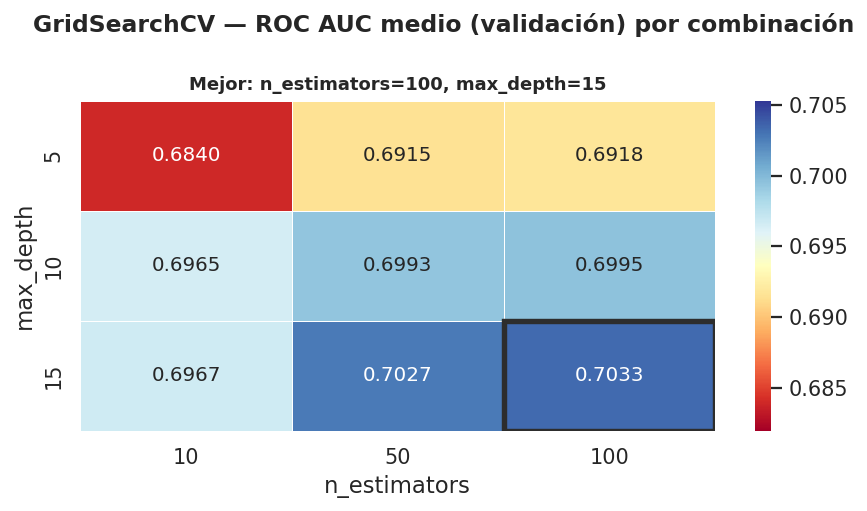

In [ ]:
# Heatmap ROC AUC por combinación de hiperparámetros
pivot = cv_table.pivot(index='max_depth', columns='n_estimators', values='AUC_val_mean')
pivot.index   = pivot.index.astype(int)
pivot.columns = pivot.columns.astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle('GridSearchCV — ROC AUC medio (validación) por combinación', fontsize=13, fontweight='bold')

sns.heatmap(
    pivot,
    annot=True, fmt='.4f',
    cmap='RdYlBu',
    vmin=pivot.values.min() - 0.002,
    vmax=pivot.values.max() + 0.002,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    ax=ax
)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')

# Marcar la mejor celda
best_ne = grid_search.best_params_['n_estimators']
best_md = grid_search.best_params_['max_depth']
best_col = list(pivot.columns).index(best_ne)
best_row = list(pivot.index).index(best_md)
ax.add_patch(plt.Rectangle((best_col, best_row), 1, 1, fill=False,
                             edgecolor='#2d2d2d', linewidth=3))
ax.set_title(f'Mejor: n_estimators={best_ne}, max_depth={best_md}', fontsize=10)

plt.tight_layout()
plt.show()

## **Evaluación Final — Mejor Modelo sobre Test**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

best_model = grid_search.best_estimator_

# Predicciones
t0 = time.time()
y_pred      = best_model.predict(X_test_sk)
y_pred_prob = best_model.predict_proba(X_test_sk)[:, 1]
t_pred = time.time() - t0

# Métricas
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-Score' : f1_score(y_test, y_pred),
    'ROC AUC'  : roc_auc_score(y_test, y_pred_prob)
}

print('── Métricas sobre Test ──')
print(f'  Mejor modelo : n_estimators={best_model.n_estimators}, max_depth={best_model.max_depth}')
print(f'  Tiempo pred  : {t_pred:.3f}s\n')
for name, val in metrics.items():
    print(f'  {name:12s}: {val:.4f}')

print(f'\n── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))

# Guardar tiempos para comparación posterior con PySpark
sk_times = {'gridsearch': t_gridsearch, 'predict': t_pred}

── Métricas sobre Test ──
  Mejor modelo : n_estimators=100, max_depth=15
  Tiempo pred  : 1.886s

  Accuracy    : 0.8006
  Precision   : 0.6570
  Recall      : 0.0021
  F1-Score    : 0.0042
  ROC AUC     : 0.7031

── Classification Report ──
              precision    recall  f1-score   support

  Fully Paid       0.80      1.00      0.89    215350
 Charged Off       0.66      0.00      0.00     53712

    accuracy                           0.80    269062
   macro avg       0.73      0.50      0.45    269062
weighted avg       0.77      0.80      0.71    269062



## **Matriz de Confusión**

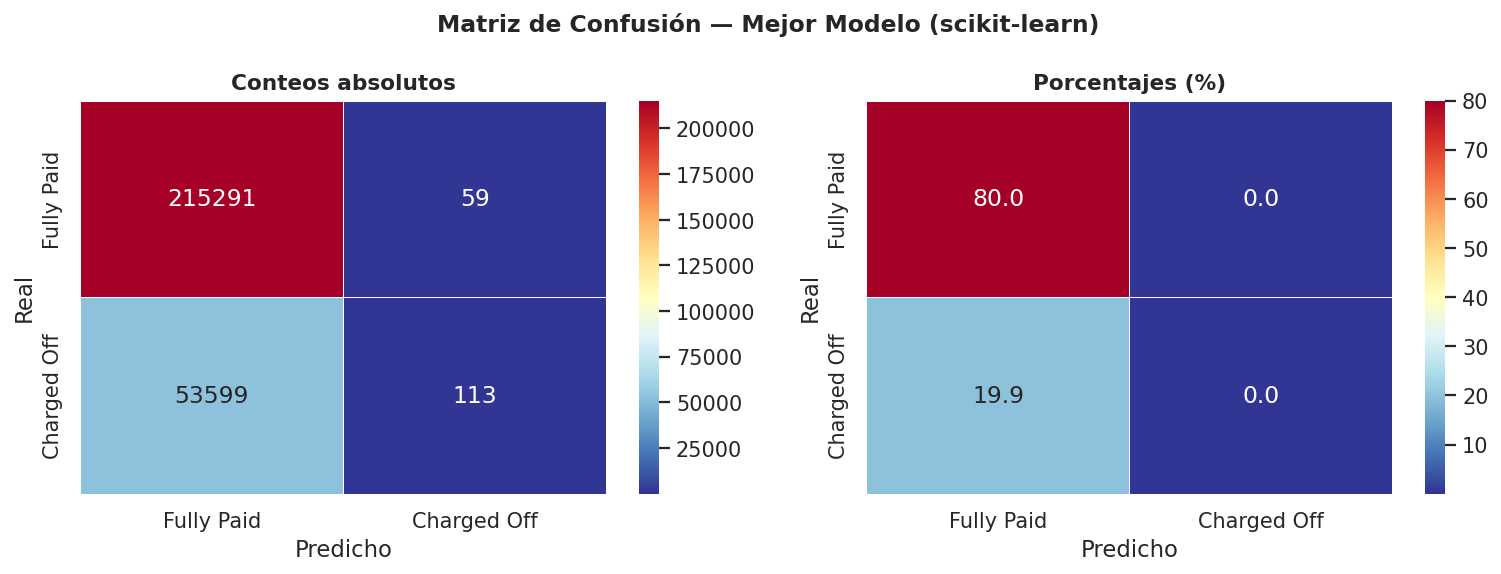

Verdaderos Negativos (TN) :  215,291  — Fully Paid correctamente identificados
Falsos Positivos     (FP) :       59  — Fully Paid clasificados como default
Falsos Negativos     (FN) :   53,599  — Defaults NO detectados
Verdaderos Positivos (TP) :      113  — Defaults correctamente detectados


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Matriz de Confusión — Mejor Modelo (scikit-learn)', fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ['d', '.1f'],
    ['Conteos absolutos', 'Porcentajes (%)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        cmap='RdYlBu_r',
        xticklabels=['Fully Paid', 'Charged Off'],
        yticklabels=['Fully Paid', 'Charged Off'],
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 13},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN) : {tn:>8,}  — Fully Paid correctamente identificados')
print(f'Falsos Positivos     (FP) : {fp:>8,}  — Fully Paid clasificados como default')
print(f'Falsos Negativos     (FN) : {fn:>8,}  — Defaults NO detectados')
print(f'Verdaderos Positivos (TP) : {tp:>8,}  — Defaults correctamente detectados')

## **Curva ROC**

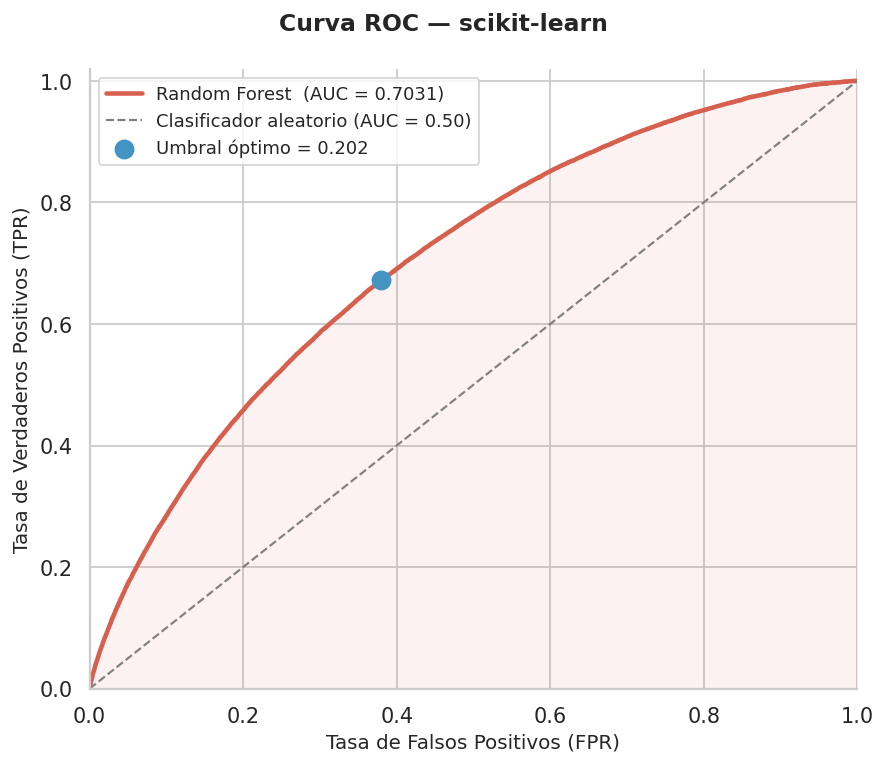

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = metrics['ROC AUC']

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Curva ROC — scikit-learn', fontsize=13, fontweight='bold')

ax.plot(fpr, tpr, color=C_DEFAULT, linewidth=2.5,
        label=f'Random Forest  (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.2,
        linestyle='--', label='Clasificador aleatorio (AUC = 0.50)')

# Punto óptimo — máximo de (TPR - FPR)
optimal_idx = (tpr - fpr).argmax()
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           color=C_PAID, s=100, zorder=5,
           label=f'Umbral óptimo = {thresholds[optimal_idx]:.3f}')

ax.fill_between(fpr, tpr, alpha=0.08, color=C_DEFAULT)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

En **GridSearchCV** la mejor combinación fue n_estimators=100, max_depth=15 con ROC AUC de 0.7033 en validación cruzada. La tabla de resultados muestra un patrón claro: max_depth=15 domina en todas las configuraciones de n_estimators, sin embargo la diferencia entre max_depth=10 y max_depth=15 es pequeña (0.6995 vs 0.7033), lo que sugiere que el modelo empieza a estabilizarse en esa profundidad. El overfitting es visible — el AUC en train (0.7510) es notablemente superior al de validación (0.7033).

El resultado más preocupante es Accuracy 0.80, ROC AUC 0.70, pero Recall de 0.0021 y F1 de 0.0042. En la matriz de confusión: 53,599 Falsos Negativos frente a apenas 113 Verdaderos Positivos. El modelo aprendió a decir "Fully Paid" casi siempre, lo que le da buen accuracy pero es inútil desde el punto de vista financiero.

## **Importancia de Features — Top 20**

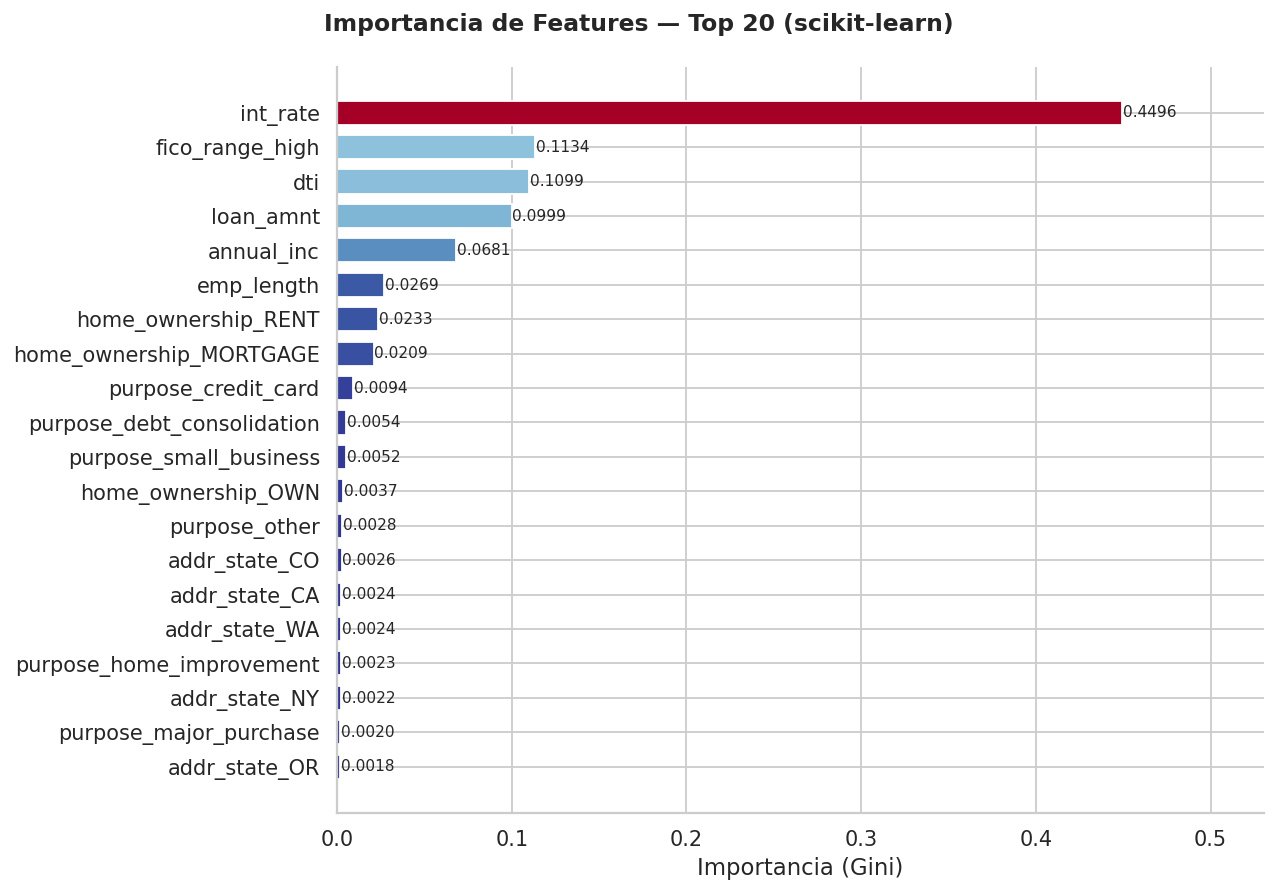

── Top 10 features ──
                   feature  importance
                  int_rate    0.449585
           fico_range_high    0.113367
                       dti    0.109900
                 loan_amnt    0.099911
                annual_inc    0.068062
                emp_length    0.026949
       home_ownership_RENT    0.023348
   home_ownership_MORTGAGE    0.020922
       purpose_credit_card    0.009377
purpose_debt_consolidation    0.005350


In [ ]:
importances = best_model.feature_importances_
fi_df = (
    pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Colorear por importancia (RdYlBu_r: rojo = más importante)
norm_fi = (fi_df['importance'] - fi_df['importance'].min()) / \
          (fi_df['importance'].max() - fi_df['importance'].min() + 1e-9)
colors = plt.cm.RdYlBu_r(norm_fi)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Importancia de Features — Top 20 (scikit-learn)', fontsize=13, fontweight='bold')

bars = ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
               color=colors[::-1], edgecolor='white', height=0.7)

for bar, val in zip(bars, fi_df['importance'][::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Importancia (Gini)')
ax.set_xlim(0, fi_df['importance'].max() * 1.18)

plt.tight_layout()
plt.show()

print('── Top 10 features ──')
print(fi_df.head(10).to_string(index=False))

int_rate domina con 44.9% de importancia. Casi la mitad del poder predictivo del modelo descansa en una sola variable. Le siguen fico_range_high (11.3%), dti (11.0%) y loan_amnt (10.0%). Las variables categóricas aportan poco individualmente, con home_ownership_RENT como la más relevante (2.3%). emp_length apenas alcanza 2.7%, confirmando lo que los gráficos del EDA anticipaban (poca capacidad discriminativa).

---
# **Modelado — PySpark**

Se replica el mismo experimento con `pyspark.ml.classification.RandomForestClassifier`. Pero con ciertas modificaciones dadas las limitaciones de PySpark en modo local (single-node). En un cluster distribuido real, estas desiciones no serian del todo necesarias.


## **Inicialización de SparkSession**

In [ ]:
!pip install pyspark --quiet

import time
from pyspark.sql import SparkSession, types as T
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType

spark = (
    SparkSession.builder
    .appName('LendingClub_DefaultPrediction')
    .master('local[*]') #usa todos los cores disponibles
    .config('spark.driver.memory', '10g') #memoria asignada al driver
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

num_cores = max(1, spark.sparkContext.defaultParallelism)
spark.conf.set('spark.sql.shuffle.partitions', str(max(8, num_cores * 4)))

print(f'SparkSession activa  |  Versión: {spark.version}')
print(f'Cores disponibles    : {num_cores}')
print(f'Shuffle partitions   : {spark.conf.get("spark.sql.shuffle.partitions")}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/18 19:50:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession activa  |  Versión: 4.0.1
Cores disponibles    : 4
Shuffle partitions   : 16


## **Carga de Datos en Spark**

Se parte de los mismos splits pandas ya limpios (`X_train`, `X_test`) para garantizar
que ambas vías usan exactamente los mismos datos.

In [ ]:
def pandas_to_spark(X, y, spark):
    """Une X e y, convierte a Spark DF con target como 'label' (DoubleType)."""
    df_pd = X.copy()
    df_pd['label'] = y.values
    sdf = spark.createDataFrame(df_pd)
    sdf = sdf.withColumn('label', F.col('label').cast(DoubleType()))
    return sdf

sdf_train_raw = pandas_to_spark(X_train, y_train, spark)
sdf_test_raw  = pandas_to_spark(X_test,  y_test,  spark)

t0 = time.time()
sdf_train_raw = sdf_train_raw.repartition(num_cores * 2).cache()
sdf_test_raw  = sdf_test_raw.repartition(num_cores * 2).cache()

n_train = sdf_train_raw.count()
n_test  = sdf_test_raw.count()
t_cache = time.time() - t0

print(f'sdf_train : {n_train:>10,} filas  (cacheado, {num_cores*2} particiones)')
print(f'sdf_test  : {n_test:>10,} filas  (cacheado, {num_cores*2} particiones)')
print(f'Cache materializado en {t_cache:.1f}s')

sdf_train :  1,076,248 filas  (cacheado, 8 particiones)
sdf_test  :    269,062 filas  (cacheado, 8 particiones)
Cache materializado en 11.3s


## **Pipeline de Preprocesamiento PySpark**

Este Pipeline presenta una **Diferencia clave respecto a sklearn:** se usa `withMean=False` en el `StandardScaler`.
Con `withMean=True`, Spark debe convertir el vector disperso (sparse) en denso (dense)
para restar la media, lo que puede multiplicar el uso de memoria por 10-50×
dependiendo del número de categorías OHE. Con `withMean=False` el vector permanece
disperso y la operación es mucho más eficiente.

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, Imputer
)
from pyspark.ml.classification import RandomForestClassifier as SparkRF

CAT_SPARK = ['purpose', 'home_ownership', 'addr_state']
NUM_SPARK = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'emp_length']

# Imputer nativo de PySpark
imputer = Imputer(
    strategy='median',
    inputCols =NUM_SPARK,
    outputCols=[f'{c}_imp' for c in NUM_SPARK]
)

# StringIndexer
indexers = [
    StringIndexer(inputCol=col, outputCol=f'{col}_idx', handleInvalid='keep')
    for col in CAT_SPARK
]

# OneHotEncoder
encoder = OneHotEncoder(
    inputCols =[f'{col}_idx' for col in CAT_SPARK],
    outputCols=[f'{col}_ohe' for col in CAT_SPARK],
    dropLast=True
)

# VectorAssembler
assembler = VectorAssembler(
    inputCols=[f'{c}_imp' for c in NUM_SPARK] + [f'{col}_ohe' for col in CAT_SPARK],
    outputCol='features',
    handleInvalid='skip'
)

# RandomForestClassifier dentro del pipeline
rf_sp = SparkRF(
    featuresCol='features',
    labelCol='label',
    seed=42
)

full_pipeline = Pipeline(
    stages=[imputer] + indexers + [encoder, assembler, rf_sp]
)

print('Stages del pipeline completo:')
for i, s in enumerate(full_pipeline.getStages()):
    print(f'  [{i+1}] {type(s).__name__}')

Stages del pipeline completo:
  [1] Imputer
  [2] StringIndexer
  [3] StringIndexer
  [4] StringIndexer
  [5] OneHotEncoder
  [6] VectorAssembler
  [7] RandomForestClassifier


## **TrainValidationSplit — Búsqueda de Hiperparámetros**

`TrainValidationSplit` evalúa cada combinación de hiperparámetros **una sola vez**
usando un split interno 80/20 sobre el conjunto de train, en lugar de los 5 folds
del `CrossValidator`.

Se toma esta descicion, dada la cantidad de registros en train, la varianza en la estimación
de métricas sobre un único split es despreciable. La ganancia
en velocidad y los limitados recursos computacionales supera ampliamente el coste estadístico en este contexto.

In [ ]:
from pyspark.ml.tuning     import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation  import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

param_grid_sp = (
    ParamGridBuilder()
    .addGrid(rf_sp.numTrees, [10, 50, 100])
    .addGrid(rf_sp.maxDepth, [5, 10, 15])
    .build()
)

evaluator_roc = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

# parallelism=max(1, num_cores // 2): entrena varios modelos del grid en paralelo
tvs = TrainValidationSplit(
    estimator          = full_pipeline,
    estimatorParamMaps = param_grid_sp,
    evaluator          = evaluator_roc,
    trainRatio         = 0.8,
    parallelism        = max(1, num_cores // 2),
    seed               = 42
)

t0 = time.time()
tvs_model       = tvs.fit(sdf_train_raw)
t_gridsearch_sp = time.time() - t0

best_model_sp = tvs_model.bestModel

print(f'\nTiempo TrainValidationSplit : {t_gridsearch_sp:.1f}s  ({t_gridsearch_sp/60:.1f} min)')
print(f'Mejor numTrees              : {best_model_sp.stages[-1].getNumTrees}')
print(f'Mejor maxDepth              : {best_model_sp.stages[-1].getMaxDepth()}')
print(f'Mejor ROC AUC               : {max(tvs_model.validationMetrics):.4f}')


Tiempo TrainValidationSplit : 2714.9s  (45.2 min)
Mejor numTrees              : 100
Mejor maxDepth              : 15
Mejor ROC AUC               : 0.7016


## **Resultados del TrainValidationSplit — Tabla Comparativa**

── Resultados TrainValidationSplit PySpark (ordenados por ROC AUC) ──
 numTrees  maxDepth  ROC_AUC_val
      100        15       0.7016
       50        15       0.7006
       10        15       0.6970
      100        10       0.6966
       50        10       0.6953
       10        10       0.6902
      100         5       0.6842
       50         5       0.6744
       10         5       0.6626


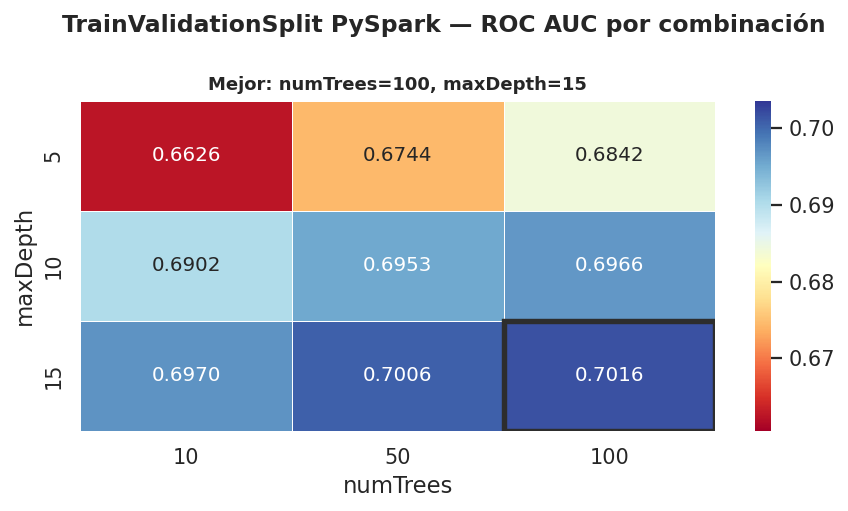

In [ ]:
# Construir tabla de resultados del grid
cv_rows = []
for params, score in zip(param_grid_sp, tvs_model.validationMetrics):
    cv_rows.append({
        'numTrees'   : params[rf_sp.numTrees],
        'maxDepth'   : params[rf_sp.maxDepth],
        'ROC_AUC_val': round(score, 4)
    })

cv_table_sp = (
    pd.DataFrame(cv_rows)
    .sort_values('ROC_AUC_val', ascending=False)
    .reset_index(drop=True)
)
print('── Resultados TrainValidationSplit PySpark (ordenados por ROC AUC) ──')
print(cv_table_sp.to_string(index=False))

# Heatmap
pivot_sp = cv_table_sp.pivot(index='maxDepth', columns='numTrees', values='ROC_AUC_val')

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle('TrainValidationSplit PySpark — ROC AUC por combinación', fontsize=13, fontweight='bold')

sns.heatmap(
    pivot_sp,
    annot=True, fmt='.4f',
    cmap='RdYlBu',
    vmin=pivot_sp.values.min() - 0.002,
    vmax=pivot_sp.values.max() + 0.002,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    ax=ax
)
ax.set_xlabel('numTrees')
ax.set_ylabel('maxDepth')

# Marcar mejor celda
best_nt = best_model_sp.stages[-1].getNumTrees
best_md = best_model_sp.stages[-1].getMaxDepth()
best_col = list(pivot_sp.columns).index(best_nt)
best_row = list(pivot_sp.index).index(best_md)
ax.add_patch(plt.Rectangle((best_col, best_row), 1, 1, fill=False,
                             edgecolor='#2d2d2d', linewidth=3))
ax.set_title(f'Mejor: numTrees={best_nt}, maxDepth={best_md}', fontsize=10)

plt.tight_layout()
plt.show()

## **Evaluación Final — Mejor Modelo sobre Test**

In [ ]:
# Predicciones sobre test (datos cacheados)
t0 = time.time()
predictions_sp = best_model_sp.transform(sdf_test_raw)
predictions_sp.cache()
_ = predictions_sp.count()   # materializar para medir tiempo real
t_pred_sp = time.time() - t0

# Métricas
evaluator_roc_test = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)

def get_mc_metric(metric, preds):
    return MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction', metricName=metric
    ).evaluate(preds)

metrics_sp = {
    'Accuracy' : get_mc_metric('accuracy',          predictions_sp),
    'Precision': get_mc_metric('weightedPrecision',  predictions_sp),
    'Recall'   : get_mc_metric('weightedRecall',     predictions_sp),
    'F1-Score' : get_mc_metric('f1',                predictions_sp),
    'ROC AUC'  : evaluator_roc_test.evaluate(predictions_sp)
}

print('── Métricas sobre Test (PySpark) ──')
print(f'  Mejor modelo : numTrees={best_model_sp.stages[-1].getNumTrees}, '
      f'maxDepth={best_model_sp.stages[-1].getMaxDepth()}')
print(f'  Tiempo pred  : {t_pred_sp:.3f}s\n')
for name, val in metrics_sp.items():
    print(f'  {name:12s}: {val:.4f}')

sp_times = {'gridsearch': t_gridsearch_sp, 'predict': t_pred_sp}

── Métricas sobre Test (PySpark) ──
  Mejor modelo : numTrees=100, maxDepth=15
  Tiempo pred  : 32.078s

  Accuracy    : 0.8007
  Precision   : 0.7767
  Recall      : 0.8007
  F1-Score    : 0.7128
  ROC AUC     : 0.7010


## **Matriz de Confusión — PySpark**

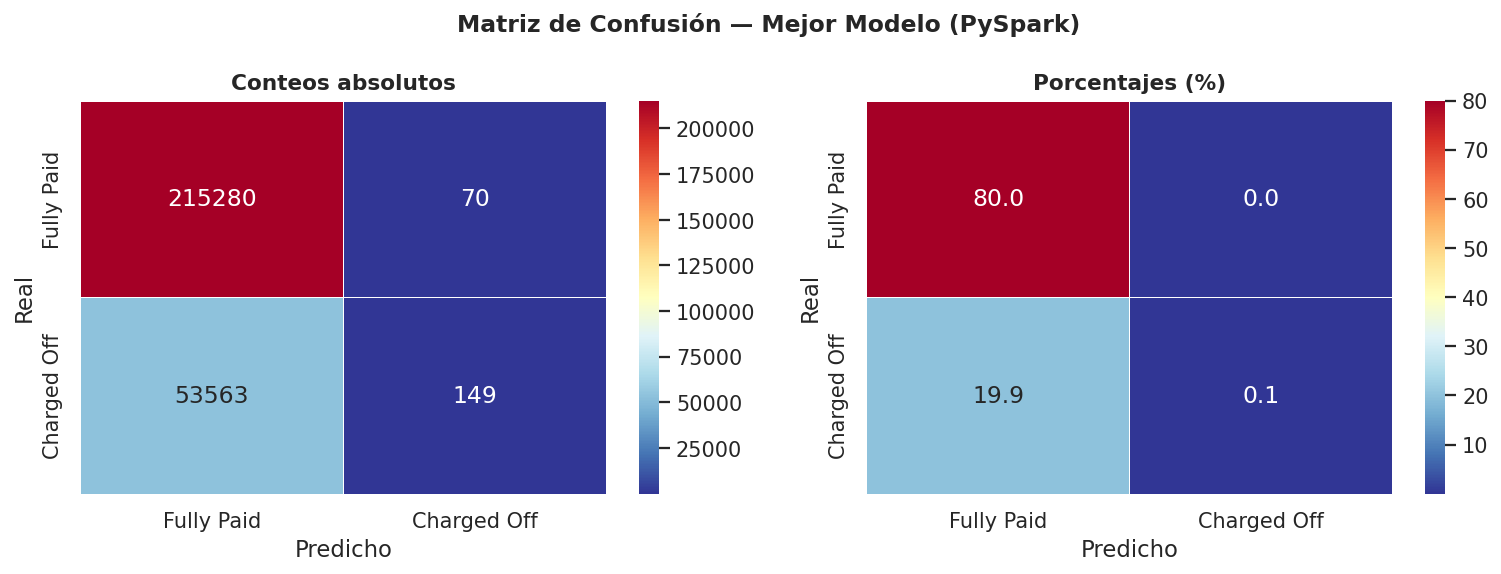

Verdaderos Negativos (TN) :  215,280  — Fully Paid correctamente identificados
Falsos Positivos     (FP) :       70  — Fully Paid clasificados como default
Falsos Negativos     (FN) :   53,563  — Defaults NO detectados
Verdaderos Positivos (TP) :      149  — Defaults correctamente detectados


In [ ]:
# Extraer predicciones a pandas para graficar
preds_pd = predictions_sp.select('label', 'prediction').toPandas()
y_test_sp   = preds_pd['label'].astype(int)
y_pred_sp   = preds_pd['prediction'].astype(int)

from sklearn.metrics import confusion_matrix
cm_sp     = confusion_matrix(y_test_sp, y_pred_sp)
cm_sp_pct = cm_sp / cm_sp.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Matriz de Confusión — Mejor Modelo (PySpark)', fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm_sp, cm_sp_pct],
    ['d', '.1f'],
    ['Conteos absolutos', 'Porcentajes (%)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        cmap='RdYlBu_r',
        xticklabels=['Fully Paid', 'Charged Off'],
        yticklabels=['Fully Paid', 'Charged Off'],
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 13},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_sp.ravel()
print(f'Verdaderos Negativos (TN) : {tn:>8,}  — Fully Paid correctamente identificados')
print(f'Falsos Positivos     (FP) : {fp:>8,}  — Fully Paid clasificados como default')
print(f'Falsos Negativos     (FN) : {fn:>8,}  — Defaults NO detectados')
print(f'Verdaderos Positivos (TP) : {tp:>8,}  — Defaults correctamente detectados')

## **Curva ROC — PySpark**

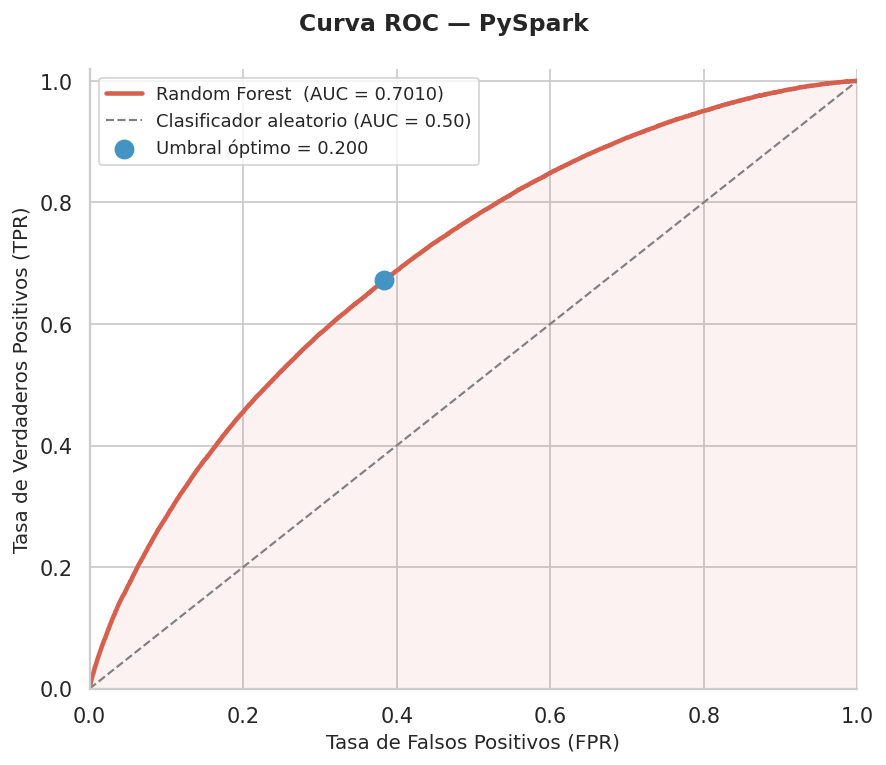

In [ ]:
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, roc_auc_score

probs_pd = (
    predictions_sp
    .withColumn('prob_1', vector_to_array('probability')[1])
    .select('label', 'prob_1')
    .toPandas()
)

fpr_sp, tpr_sp, thr_sp = roc_curve(probs_pd['label'], probs_pd['prob_1'])
roc_auc_sp = roc_auc_score(probs_pd['label'], probs_pd['prob_1'])  # ← añade esta línea

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Curva ROC — PySpark', fontsize=13, fontweight='bold')

ax.plot(fpr_sp, tpr_sp, color=C_DEFAULT, linewidth=2.5,
        label=f'Random Forest  (AUC = {roc_auc_sp:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.2,
        linestyle='--', label='Clasificador aleatorio (AUC = 0.50)')

optimal_idx_sp = (tpr_sp - fpr_sp).argmax()
ax.scatter(fpr_sp[optimal_idx_sp], tpr_sp[optimal_idx_sp],
           color=C_PAID, s=100, zorder=5,
           label=f'Umbral óptimo = {thr_sp[optimal_idx_sp]:.3f}')

ax.fill_between(fpr_sp, tpr_sp, alpha=0.08, color=C_DEFAULT)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## **Importancia de Features — Top 20 (PySpark)**

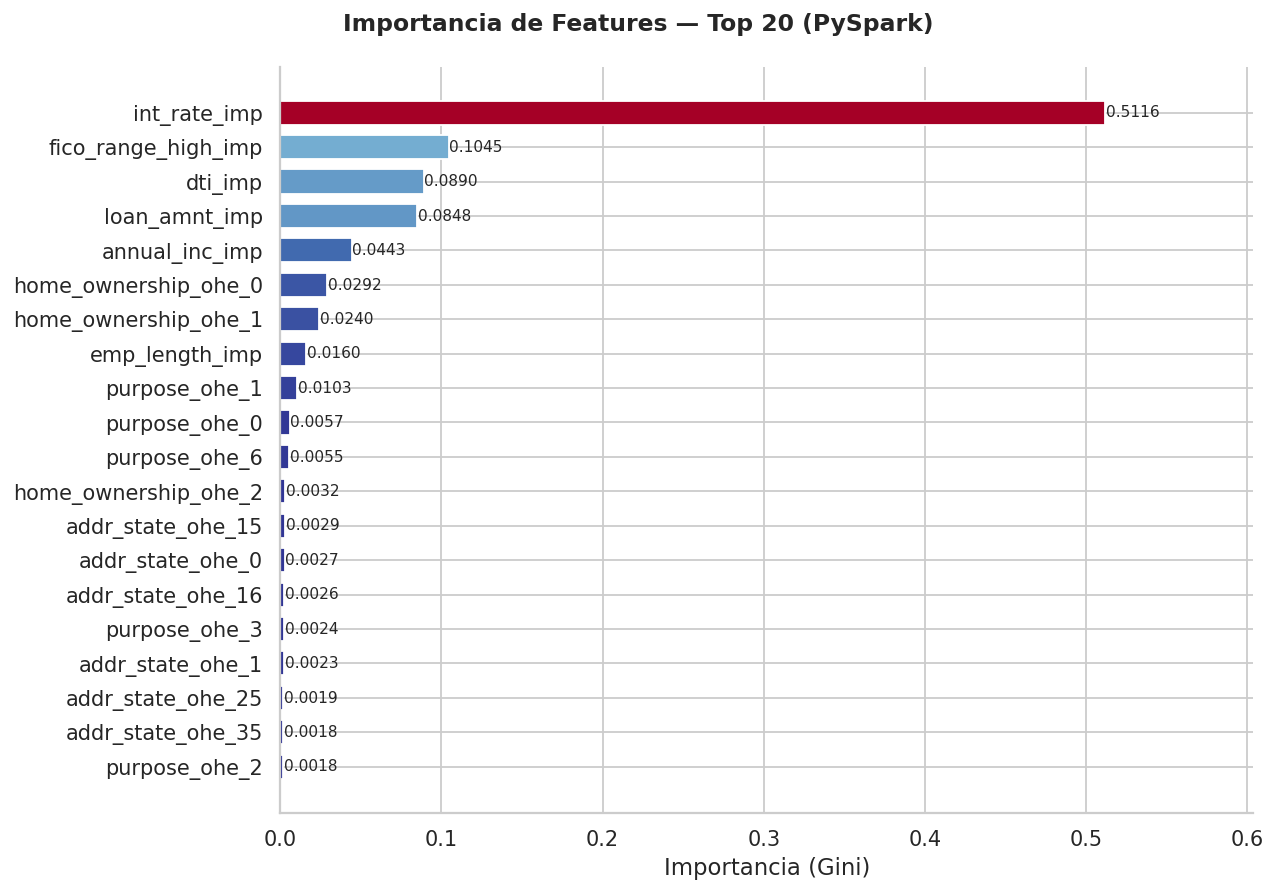

In [ ]:
rf_model_sp = best_model_sp.stages[-1]
fi_sp = rf_model_sp.featureImportances.toArray()

# Nombres de features: numéricas imputadas + OHE
ohe_names_sp = [
    f'{col}_ohe_{i}'
    for col in CAT_SPARK
    for i in range(
        best_model_sp.stages[
            list(type(s).__name__ for s in best_model_sp.stages).index('OneHotEncoderModel')
        ].categorySizes[CAT_SPARK.index(col)] - 1
    )
]
all_names_sp = [f'{c}_imp' for c in NUM_SPARK] + ohe_names_sp

if len(fi_sp) != len(all_names_sp):
    all_names_sp = [f'feature_{i}' for i in range(len(fi_sp))]

fi_df_sp = (
    pd.DataFrame({'feature': all_names_sp, 'importance': fi_sp})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

norm_fi_sp = (fi_df_sp['importance'] - fi_df_sp['importance'].min()) / \
             (fi_df_sp['importance'].max() - fi_df_sp['importance'].min() + 1e-9)
colors_sp = plt.cm.RdYlBu_r(norm_fi_sp)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Importancia de Features — Top 20 (PySpark)', fontsize=13, fontweight='bold')

bars = ax.barh(fi_df_sp['feature'][::-1], fi_df_sp['importance'][::-1],
               color=colors_sp[::-1], edgecolor='white', height=0.7)

for bar, val in zip(bars, fi_df_sp['importance'][::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Importancia (Gini)')
ax.set_xlim(0, fi_df_sp['importance'].max() * 1.18)
plt.tight_layout()
plt.show()

### Detener SparkSession

In [ ]:
spark.stop()

En TrainValidationSplit misma mejor combinación que sklearn: numTrees=100, maxDepth=15, ROC AUC de 0.7016 en el split de validación. El ranking de combinaciones es idéntico al de sklearn, lo que confirma que ambas implementaciones del algoritmo convergen a las mismas conclusiones sobre el espacio de hiperparámetros.

Por otro lado, la implementacion con Pyspark obtuvo Accuracy 0.8007, ROC AUC 0.7010, Recall 0.80, F1 0.71. A primera vista parece mucho mejor que sklearn, pero hay que leerlo con cuidado. En la matriz de confusión hay: 53,563 Falsos Negativos, prácticamente igual que sklearn. El problema del umbral es el mismo. Esto es debido a que  El Precision de 0.7767 y el Recall de 0.8007 son métricas ponderadas (weightedPrecision, weightedRecall) que incluyen ambas clases. No son comparables directamente con el Precision y Recall de sklearn, que están calculados solo para la clase positiva (default).

---
## **Comparación Final — scikit-learn vs PySpark**

In [ ]:
# Tabla comparativa de métricas
comparison = pd.DataFrame({
    'Métrica'     : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC',
                     'Tiempo GridSearch (s)', 'Tiempo Predicción (s)'],
    'scikit-learn': [
        metrics['Accuracy'], metrics['Precision'], metrics['Recall'],
        metrics['F1-Score'], metrics['ROC AUC'],
        round(sk_times['gridsearch'], 2), round(sk_times['predict'], 3)
    ],
    'PySpark'     : [
        metrics_sp['Accuracy'], metrics_sp['Precision'], metrics_sp['Recall'],
        metrics_sp['F1-Score'], metrics_sp['ROC AUC'],
        round(sp_times['gridsearch'], 2), round(sp_times['predict'], 3)
    ]
})
comparison['Diferencia'] = (
    comparison['scikit-learn'] - comparison['PySpark']
).round(4)

print('── Tabla comparativa sklearn vs PySpark ──\n')
print(comparison.to_string(index=False))

── Tabla comparativa sklearn vs PySpark ──

              Métrica  scikit-learn     PySpark  Diferencia
             Accuracy      0.800574    0.800667     -0.0001
            Precision      0.656977    0.776730     -0.1198
               Recall      0.002104    0.800667     -0.7986
             F1-Score      0.004194    0.712821     -0.7086
              ROC AUC      0.703053    0.701027      0.0020
Tiempo GridSearch (s)   1209.670000 2714.910000  -1505.2400
Tiempo Predicción (s)      1.886000   32.078000    -30.1920


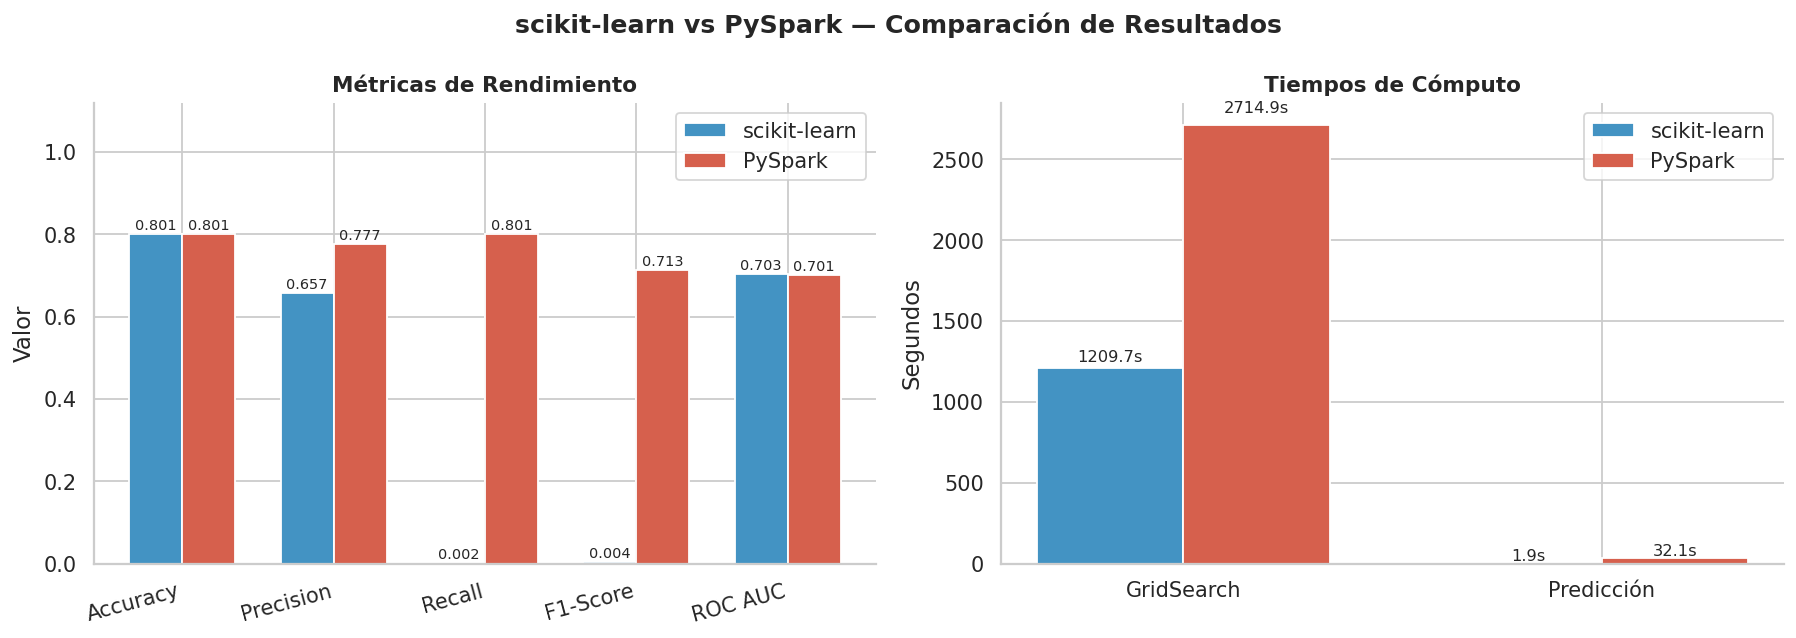

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('scikit-learn vs PySpark — Comparación de Resultados', fontsize=14, fontweight='bold')

# Métricas de rendimiento
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
sk_vals  = [metrics[m]    for m in metric_names]
sp_vals  = [metrics_sp[m] for m in metric_names]

x    = np.arange(len(metric_names))
w    = 0.35
bars1 = axes[0].bar(x - w/2, sk_vals, w, label='scikit-learn', color=C_PAID,    edgecolor='white')
bars2 = axes[0].bar(x + w/2, sp_vals, w, label='PySpark',      color=C_DEFAULT, edgecolor='white')

for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=15, ha='right')
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Valor')
axes[0].set_title('Métricas de Rendimiento')
axes[0].legend()

# Tiempos de cómputo
time_labels = ['GridSearch', 'Predicción']
sk_t = [sk_times['gridsearch'], sk_times['predict']]
sp_t = [sp_times['gridsearch'], sp_times['predict']]

x2 = np.arange(len(time_labels))
axes[1].bar(x2 - w/2, sk_t, w, label='scikit-learn', color=C_PAID,    edgecolor='white')
axes[1].bar(x2 + w/2, sp_t, w, label='PySpark',      color=C_DEFAULT, edgecolor='white')

for bars, vals in [([axes[1].patches[i] for i in range(2)], sk_t),
                   ([axes[1].patches[i] for i in range(2, 4)], sp_t)]:
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                     f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x2)
axes[1].set_xticklabels(time_labels)
axes[1].set_ylabel('Segundos')
axes[1].set_title('Tiempos de Cómputo')
axes[1].legend()

plt.tight_layout()
plt.show()

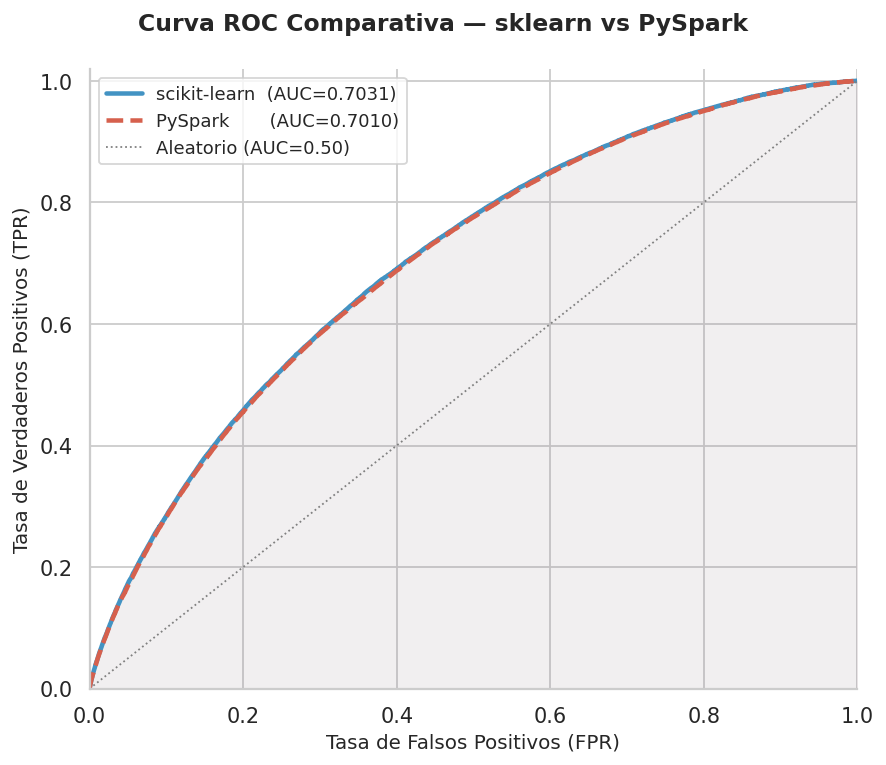

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Curva ROC Comparativa — sklearn vs PySpark', fontsize=13, fontweight='bold')

ax.plot(fpr,    tpr,    color=C_PAID,    linewidth=2.5, label=f'scikit-learn  (AUC={metrics["ROC AUC"]:.4f})')
ax.plot(fpr_sp, tpr_sp, color=C_DEFAULT, linewidth=2.5, linestyle='--', label=f'PySpark       (AUC={roc_auc_sp:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle=':', label='Aleatorio (AUC=0.50)')

ax.fill_between(fpr,    tpr,    alpha=0.06, color=C_PAID)
ax.fill_between(fpr_sp, tpr_sp, alpha=0.06, color=C_DEFAULT)

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

**Tiempos**

sklearn completó el GridSearch en 20.2 minutos, PySpark tardó 45.2 minutos — más del doble. En predicción la diferencia es aún más pronunciada: 1.9s vs 32s. Esto confirma que en un entorno local de una sola máquina, PySpark introduce overhead que supera sus beneficios. PySpark cobra ventaja en clusters distribuidos con datasets muchisimos mas grandes que no caben en memoria.

---
# **Interpretabilidad — LIME**

LIME (*Local Interpretable Model-agnostic Explanations*) explica **predicciones individuales**
de cualquier modelo caja negra localmente .

## **Instalación y Configuración del Explainer**

In [ ]:
!pip install lime --quiet

import lime
import lime.lime_tabular
from sklearn.metrics import confusion_matrix

# ── Reconstruir nombres de features categóricas para LIME ────────────────────
# LIME necesita saber qué posiciones del vector son categóricas (OHE)
ohe_feature_names = preprocessor.named_transformers_['cat'] \
                    .get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names  = NUM_FEATURES + ohe_feature_names

# Índices de las features categóricas (OHE) en el vector final
cat_indices = list(range(len(NUM_FEATURES), len(all_feature_names)))

# ── LimeTabularExplainer ─────────────────────────────────────────────────────
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train_sk,
    feature_names   = all_feature_names,
    class_names     = ['Fully Paid', 'Charged Off'],
    categorical_features = cat_indices,
    mode            = 'classification',
    random_state    = 42
)

print(f'LimeTabularExplainer configurado')
print(f'  Features totales     : {len(all_feature_names)}')
print(f'  Features numéricas   : {len(NUM_FEATURES)}')
print(f'  Features categóricas : {len(cat_indices)}')

LimeTabularExplainer configurado
  Features totales     : 77
  Features numéricas   : 6
  Features categóricas : 71


## **Selección de Instancias Mal Clasificadas**

In [ ]:
y_pred      = best_model.predict(X_test_sk)
y_pred_prob = best_model.predict_proba(X_test_sk)[:, 1]

import numpy as np

# Índices de errores
fp_idx = np.where((y_pred == 1) & (y_test.values == 0))[0]  # Falsos Positivos
fn_idx = np.where((y_pred == 0) & (y_test.values == 1))[0]  # Falsos Negativos

# Seleccionar la instancia con probabilidad más cercana al umbral en cada grupo
# — son los casos más 'confusos' para el modelo y los más informativos para LIME
fp_instance_idx = fp_idx[np.argmin(np.abs(y_pred_prob[fp_idx] - 0.5))]
fn_instance_idx = fn_idx[np.argmin(np.abs(y_pred_prob[fn_idx] - 0.5))]

print(f'Falsos Positivos totales : {len(fp_idx):,}')
print(f'Falsos Negativos totales : {len(fn_idx):,}')
print(f'\nInstancia FP seleccionada (idx={fp_instance_idx})')
print(f'  Real: Fully Paid (0)  |  Predicho: Charged Off (1)  |  P(default)={y_pred_prob[fp_instance_idx]:.4f}')
print(f'\nInstancia FN seleccionada (idx={fn_instance_idx})')
print(f'  Real: Charged Off (1)  |  Predicho: Fully Paid (0)  |  P(default)={y_pred_prob[fn_instance_idx]:.4f}')

Falsos Positivos totales : 59
Falsos Negativos totales : 53,599

Instancia FP seleccionada (idx=227654)
  Real: Fully Paid (0)  |  Predicho: Charged Off (1)  |  P(default)=0.5002

Instancia FN seleccionada (idx=22902)
  Real: Charged Off (1)  |  Predicho: Fully Paid (0)  |  P(default)=0.4999


Estas selecciones no sonn casualidad ni arbitrarias, se seleccionaron explícitamente como los casos más cercanos a 0.5 para maximizar la informatividad de la explicación. Son los préstamos donde el modelo estuvo más confuso.

## **Explicación — Falso Positivo (pagó bien pero fue predicho como default)**

Préstamo que **pagó correctamente** pero el modelo predijo como *default*.
Las variables en rojo empujaron la predicción hacia *Charged Off*;
las azules la empujaron hacia *Fully Paid*.

── Falso Positivo — P(Charged Off) = 0.5002 ──
Real: Fully Paid (0)  |  Predicho: Charged Off (1)

                  Feature  Contribución             Dirección
          int_rate > 0.58      0.119701 → Charged Off (error)
 purpose_small_business=0     -0.044888          → Fully Paid
               dti > 0.71      0.036017 → Charged Off (error)
 fico_range_high <= -0.82      0.031198 → Charged Off (error)
          addr_state_VT=0     -0.028426          → Fully Paid
home_ownership_MORTGAGE=0      0.023594 → Charged Off (error)
      annual_inc <= -0.61      0.022094 → Charged Off (error)
          addr_state_NH=0      0.020740 → Charged Off (error)
          addr_state_NE=0     -0.020081          → Fully Paid
        purpose_wedding=0      0.018348 → Charged Off (error)


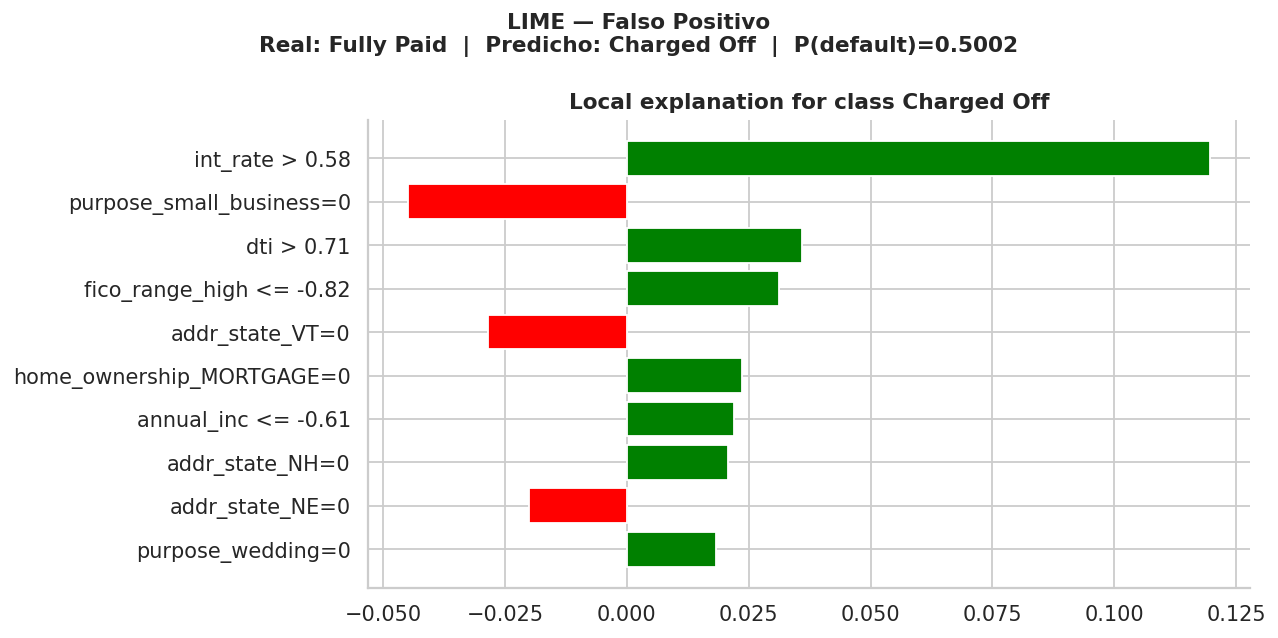

In [ ]:
exp_fp = explainer.explain_instance(
    data_row       = X_test_sk[fp_instance_idx],
    predict_fn     = best_model.predict_proba,
    num_features   = 10,
    labels         = (1,)   # explicar la clase 'Charged Off'
)

print(f'── Falso Positivo — P(Charged Off) = {y_pred_prob[fp_instance_idx]:.4f} ──')
print(f'Real: Fully Paid (0)  |  Predicho: Charged Off (1)\n')

# Tabla de contribuciones
fp_contributions = exp_fp.as_list(label=1)
fp_df = pd.DataFrame(fp_contributions, columns=['Feature', 'Contribución'])
fp_df['Dirección'] = fp_df['Contribución'].apply(
    lambda x: '→ Charged Off (error)' if x > 0 else '→ Fully Paid'
)
print(fp_df.to_string(index=False))

# Gráfico
fig = exp_fp.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
fig.suptitle('LIME — Falso Positivo\n'
             f'Real: Fully Paid  |  Predicho: Charged Off  |  P(default)={y_pred_prob[fp_instance_idx]:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

int_rate > 0.58 es la contribución más fuerte hacia Charged Off (0.12), seguida de dti > 0.71 y fico_range_high <= -0.82. El modelo fue penalizado por una tasa de interés alta y un DTI elevado, variables que estadísticamente predicen default, pero este préstamo particular fue pagado.

## **Explicación — Falso Negativo (hizo default pero fue predicho como pagado)**

Préstamo que **hizo default** pero el modelo predijo como *Fully Paid*.
Este es el error más costoso desde el punto de vista financiero.

── Falso Negativo — P(Charged Off) = 0.4999 ──
Real: Charged Off (1)  |  Predicho: Fully Paid (0)

                 Feature  Contribución            Dirección
         int_rate > 0.58      0.119606        → Charged Off
         addr_state_ND=0     -0.041748 → Fully Paid (error)
    home_ownership_ANY=0      0.041378        → Charged Off
purpose_small_business=0     -0.040409 → Fully Paid (error)
              dti > 0.71      0.038381        → Charged Off
        loan_amnt > 0.64      0.036759        → Charged Off
      purpose_vacation=0     -0.027514 → Fully Paid (error)
         addr_state_AR=0     -0.025360 → Fully Paid (error)
         addr_state_ME=0      0.025199        → Charged Off
   purpose_educational=0      0.013747        → Charged Off


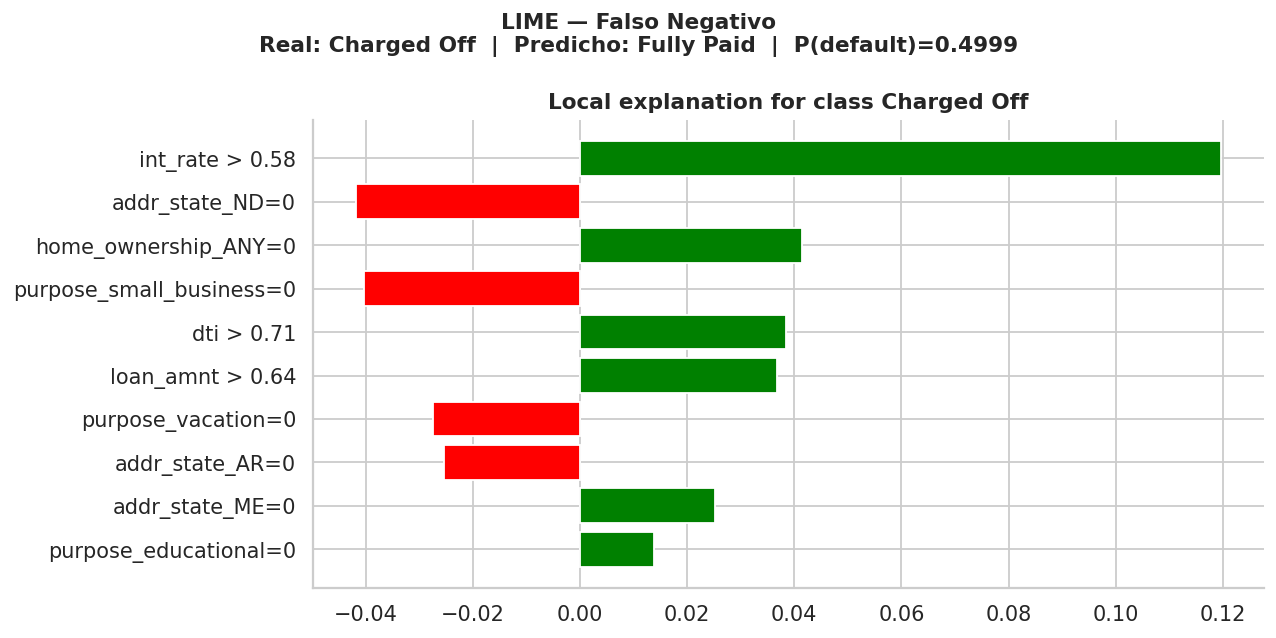

In [ ]:
exp_fn = explainer.explain_instance(
    data_row       = X_test_sk[fn_instance_idx],
    predict_fn     = best_model.predict_proba,
    num_features   = 10,
    labels         = (1,)   # explicar la clase 'Charged Off'
)

print(f'── Falso Negativo — P(Charged Off) = {y_pred_prob[fn_instance_idx]:.4f} ──')
print(f'Real: Charged Off (1)  |  Predicho: Fully Paid (0)\n')

# Tabla de contribuciones
fn_contributions = exp_fn.as_list(label=1)
fn_df = pd.DataFrame(fn_contributions, columns=['Feature', 'Contribución'])
fn_df['Dirección'] = fn_df['Contribución'].apply(
    lambda x: '→ Charged Off' if x > 0 else '→ Fully Paid (error)'
)
print(fn_df.to_string(index=False))

# Gráfico
fig = exp_fn.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
fig.suptitle('LIME — Falso Negativo\n'
             f'Real: Charged Off  |  Predicho: Fully Paid  |  P(default)={y_pred_prob[fn_instance_idx]:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

int_rate > 0.58 también lidera hacia Charged Off (0.12), pero múltiples variables de estado (addr_state_ND=0, addr_state_AR=0) empujaron hacia Fully Paid con fuerza suficiente para cruzar el umbral, estas variables tienen contribuciones negativas porque el modelo aprendió que ciertos estados tienen tasas de default más bajas, y la ausencia de esos estados empuja hacia riesgo.

## **Comparación de Contribuciones — FP vs FN**

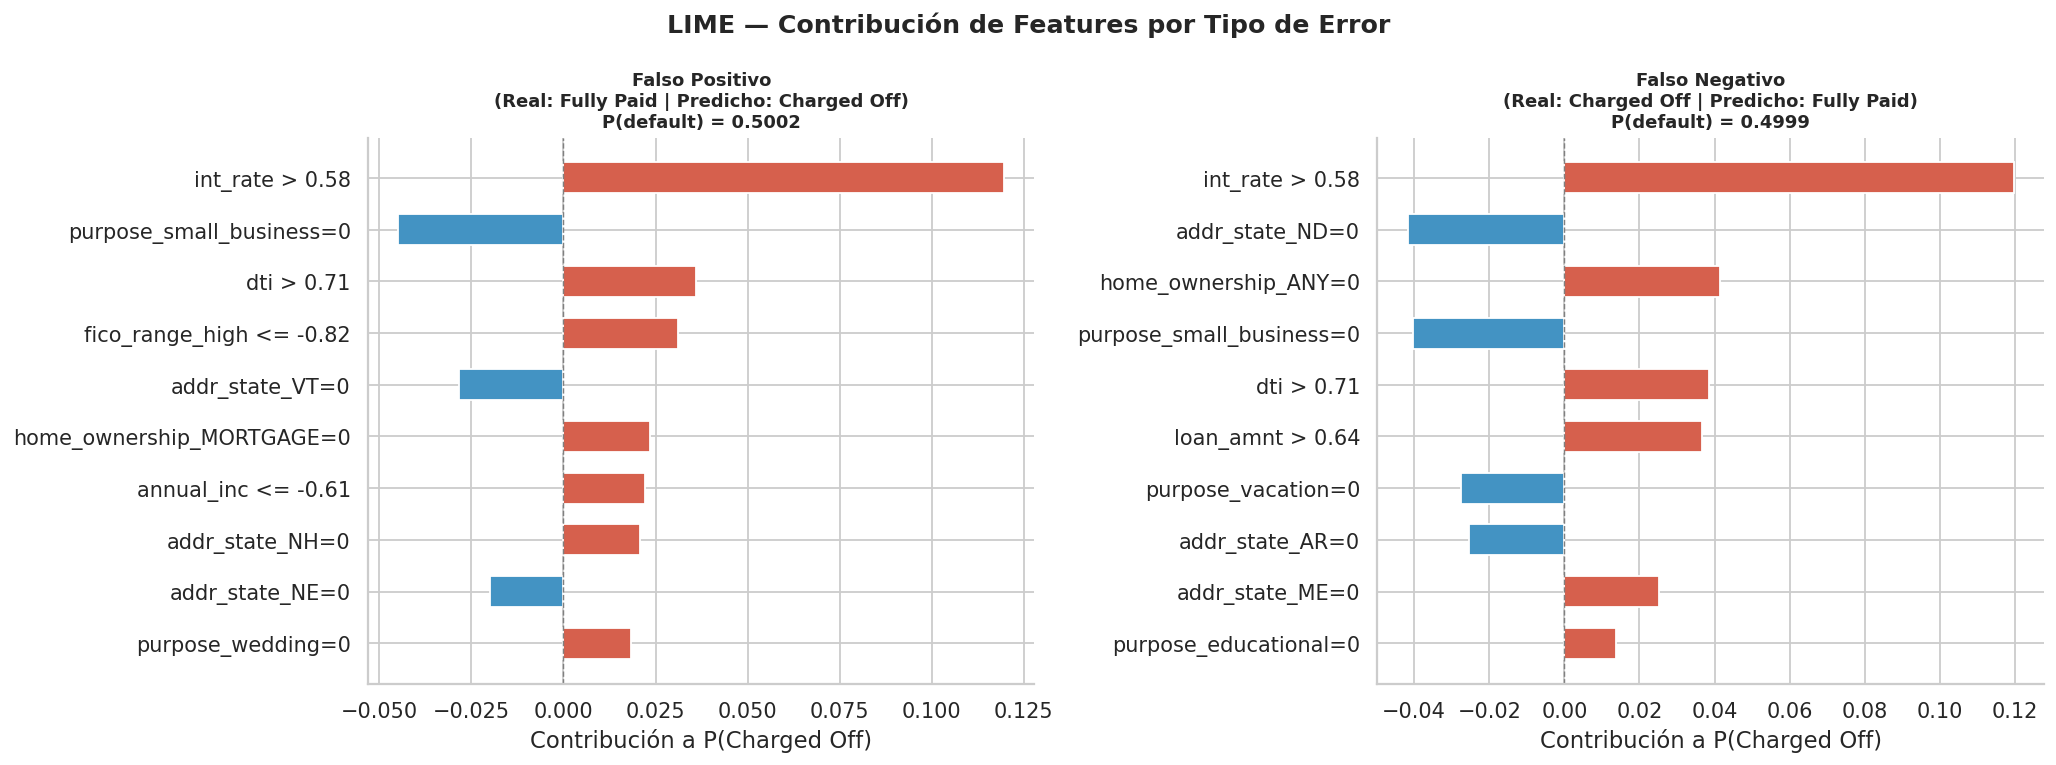

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LIME — Contribución de Features por Tipo de Error', fontsize=14, fontweight='bold')

for ax, contributions, title, pred_prob in zip(
    axes,
    [fp_contributions, fn_contributions],
    ['Falso Positivo\n(Real: Fully Paid | Predicho: Charged Off)',
     'Falso Negativo\n(Real: Charged Off | Predicho: Fully Paid)'],
    [y_pred_prob[fp_instance_idx], y_pred_prob[fn_instance_idx]]
):
    features = [x[0] for x in contributions]
    values   = [x[1] for x in contributions]
    colors   = [C_DEFAULT if v > 0 else C_PAID for v in values]

    ax.barh(features[::-1], values[::-1], color=colors[::-1],
            edgecolor='white', height=0.6)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{title}\nP(default) = {pred_prob:.4f}', fontsize=10)
    ax.set_xlabel('Contribución a P(Charged Off)')

plt.tight_layout()
plt.show()

**Patrón común**
En ambas instancias int_rate es la variable más influyente, coherente con su 44.9% de importancia global. LIME confirma a nivel local lo que la importancia de features muestra globalmente. Esto da confianza en que el modelo no está usando correlaciones casuales. La variable más importante es también la más intuitiva desde el punto de vista financiero.

# **Reflexion Final**
Ambos frameworks llegaron a la misma conclusión sobre el espacio de hiperparámetros. La diferencia de rendimiento es despreciable. La diferencia de tiempo es sustancial, PySpark tardó más del doble en el grid search y 17 veces más en predicción.
Esto no significa que PySpark sea inferior. Significa que en un entorno local de una sola máquina, el overhead supera sus beneficios. PySpark cobra sentido cuando el dataset no cabe en memoria de un solo nodo o cuando existe un cluster distribuido real. Para este problema en este entorno, sklearn es la herramienta correcta.